# Chapter 38: Capacity Arrives When the Price Has Gone

*Systems Thinking with AI* by Jason Karpeles

A loop with two delays and nothing outside it can swing like a public record, which proves little.

**Goal.** Four demonstrations on a one-stock capacity loop fitted to the committed Federal Reserve manufacturing utilization record. Read the two statistics the fit is scored on, compare four investment rules, move the construction delay, and start the loop at different points in its cycle. Fitted values are inferred from the record, varied values are constructed, and nothing here is a forecast.

**Demonstrations**

1. Period and amplitude, not the path
2. Sensible at every step, and still a cycle
3. The construction delay carries the period
4. A period is not a date

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/38-capacity-cycle/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/38-capacity-cycle/reader.html).

The observed series is the committed public record used by the chapter (Federal Reserve total industry capacity utilization, monthly). Fitted values are inferred from that record, and nothing here is a forecast.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The public record

The chapter reads its observed series from these files. They are written into a working folder so the model code reads them exactly as the book does.

In [2]:
RECORD_FILES = {}
RECORD_FILES['data/fred_capacity/capacity_monthly.csv'] = '''\
period,utilization,capacity_index,production_index,ppi
1972-01-01,81.3263,48.5415,36.0361,
1972-02-01,81.7334,48.6572,36.3103,
1972-03-01,82.0640,48.7754,36.5521,
1972-04-01,82.7916,48.8961,36.9727,
1972-05-01,82.7283,49.0185,37.0413,
1972-06-01,82.7590,49.1440,37.1530,
1972-07-01,82.5143,49.2723,37.1417,
1972-08-01,83.4014,49.4053,37.6426,
1972-09-01,83.7842,49.5436,37.9199,
1972-10-01,84.7869,49.6879,38.4827,
1972-11-01,85.6348,49.8384,38.9812,
1972-12-01,86.5955,49.9940,39.5366,
1973-01-01,86.9894,50.1528,39.8364,
1973-02-01,88.0924,50.3169,40.4666,
1973-03-01,87.9762,50.4854,40.5415,
1973-04-01,87.5646,50.6567,40.4817,
1973-05-01,87.8683,50.8314,40.7559,
1973-06-01,87.6049,51.0092,40.7705,
1973-07-01,87.6941,51.1868,40.9505,
1973-08-01,87.1662,51.3633,40.8430,
1973-09-01,87.5986,51.5382,41.1864,
1973-10-01,88.1969,51.7108,41.6101,
1973-11-01,88.5022,51.8803,41.8970,
1973-12-01,88.2141,52.0449,41.9012,
1974-01-01,87.1839,52.2070,41.5515,
1974-02-01,86.5250,52.3634,41.3730,
1974-03-01,86.2017,52.5145,41.3508,
1974-04-01,85.5700,52.6582,41.1748,
1974-05-01,85.9091,52.7962,41.4617,
1974-06-01,85.7225,52.9284,41.4908,
1974-07-01,85.4801,53.0533,41.4859,
1974-08-01,84.4575,53.1718,41.0948,
1974-09-01,84.3512,53.2850,41.1427,
1974-10-01,83.5988,53.3933,40.8692,
1974-11-01,80.8620,53.4942,39.6142,
1974-12-01,76.9591,53.5902,37.7762,
1975-01-01,75.1821,53.6819,36.9716,
1975-02-01,72.9414,53.7712,35.9323,
1975-03-01,71.7965,53.8578,35.4268,
1975-04-01,71.7238,53.9417,35.4464,
1975-05-01,71.4412,54.0252,35.3608,
1975-06-01,71.9392,54.1098,35.6617,
1975-07-01,72.8822,54.1952,36.1844,
1975-08-01,73.5302,54.2837,36.5639,
1975-09-01,74.6851,54.3753,37.1993,
1975-10-01,74.9719,54.4709,37.4066,
1975-11-01,74.9998,54.5703,37.4881,
1975-12-01,75.9111,54.6735,38.0151,
1976-01-01,76.6838,54.7801,38.4775,
1976-02-01,77.7193,54.8925,39.0789,
1976-03-01,77.7910,55.0086,39.2002,
1976-04-01,78.0262,55.1277,39.4075,
1976-05-01,78.2420,55.2500,39.6087,
1976-06-01,78.1338,55.3755,39.6494,
1976-07-01,78.5010,55.5027,39.9339,
1976-08-01,78.7944,55.6314,40.1839,
1976-09-01,78.8088,55.7615,40.2940,
1976-10-01,78.4834,55.8934,40.2320,
1976-11-01,79.3260,56.0275,40.7719,
1976-12-01,79.9902,56.1630,41.2237,
1977-01-01,79.4764,56.2983,41.0686,
1977-02-01,80.7201,56.4400,41.8282,
1977-03-01,81.6800,56.5841,42.4457,
1977-04-01,82.2715,56.7297,42.8751,
1977-05-01,82.7162,56.8783,43.2315,
1977-06-01,83.2250,57.0304,43.6251,
1977-07-01,82.9856,57.1844,43.6276,
1977-08-01,83.1840,57.3404,43.8610,
1977-09-01,82.9395,57.4984,43.8618,
1977-10-01,82.8750,57.6582,43.9582,
1977-11-01,82.8484,57.8196,44.0755,
1977-12-01,83.5391,57.9811,44.5754,
1978-01-01,81.9897,58.1418,43.8780,
1978-02-01,82.0432,58.3033,44.0373,
1978-03-01,83.2356,58.4645,44.8104,
1978-04-01,84.3363,58.6245,45.5378,
1978-05-01,84.4961,58.7846,45.7604,
1978-06-01,84.8750,58.9452,46.1042,
1978-07-01,84.5510,59.1051,46.0669,
1978-08-01,84.7645,59.2648,46.3234,
1978-09-01,84.9482,59.4249,46.5658,
1978-10-01,85.2693,59.5858,46.8862,
1978-11-01,85.8134,59.7467,47.3315,
1978-12-01,86.1466,59.9073,47.6629,
1979-01-01,85.2649,60.0673,47.3218,
1979-02-01,85.2437,60.2266,47.4565,
1979-03-01,85.4024,60.3855,47.6915,
1979-04-01,83.6948,60.5420,46.8799,
1979-05-01,84.6361,60.6968,47.5493,
1979-06-01,84.4943,60.8494,47.6094,
1979-07-01,84.3061,60.9972,47.6382,
1979-08-01,82.9669,61.1395,47.0091,
1979-09-01,82.8412,61.2767,47.0605,
1979-10-01,83.1022,61.4090,47.3272,
1979-11-01,82.5987,61.5363,47.1535,
1979-12-01,82.6737,61.6587,47.3050,
1980-01-01,82.9163,61.7767,47.5493,
1980-02-01,82.6085,61.8923,47.4753,
1980-03-01,81.7621,62.0057,47.0886,
1980-04-01,79.8787,62.1174,46.1007,
1980-05-01,77.2273,62.2299,44.6651,
1980-06-01,75.8022,62.3450,43.9365,
1980-07-01,74.7887,62.4625,43.4461,
1980-08-01,75.1572,62.5835,43.7616,
1980-09-01,76.2680,62.7096,44.5154,
1980-10-01,77.5196,62.8412,45.3594,
1980-11-01,78.7211,62.9789,46.1823,
1980-12-01,78.8116,63.1213,46.3588,
1981-01-01,78.2623,63.2682,46.1616,
1981-02-01,77.6504,63.4211,45.9281,
1981-03-01,77.6822,63.5780,46.0765,
1981-04-01,77.8733,63.7369,46.3206,
1981-05-01,78.0030,63.8983,46.5291,
1981-06-01,77.3998,64.0615,46.2994,
1981-07-01,77.3594,64.2243,46.4033,
1981-08-01,77.1186,64.3851,46.3841,
1981-09-01,76.5985,64.5438,46.1930,
1981-10-01,75.6008,64.6994,45.7088,
1981-11-01,74.4126,64.8510,45.1031,
1981-12-01,72.9463,64.9972,44.3210,
1982-01-01,70.9514,65.1369,43.2086,
1982-02-01,72.8305,65.2723,44.4528,
1982-03-01,72.1351,65.4002,44.1227,
1982-04-01,71.4507,65.5191,43.7924,
1982-05-01,71.1775,65.6300,43.7082,
1982-06-01,70.9848,65.7326,43.6682,
1982-07-01,70.7904,65.8253,43.6209,
1982-08-01,69.9876,65.9074,43.1911,
1982-09-01,69.7678,65.9793,43.1135,
1982-10-01,68.7764,66.0412,42.5515,
1982-11-01,68.2819,66.0934,42.2892,
1982-12-01,68.0089,66.1367,42.1574,
1983-01-01,69.5631,66.1720,43.1531,
1983-02-01,69.4819,66.2011,43.1294,
1983-03-01,70.1339,66.2250,43.5567,
1983-04-01,70.9570,66.2454,44.0875,
1983-05-01,71.7993,66.2644,44.6288,
1983-06-01,72.3736,66.2842,45.0032,
1983-07-01,73.4363,66.3066,45.6826,
1983-08-01,74.0140,66.3346,46.0638,
1983-09-01,75.3866,66.3699,46.9454,
1983-10-01,76.1156,66.4138,47.4335,
1983-11-01,76.4305,66.4676,47.6717,
1983-12-01,76.6136,66.5313,47.8363,
1984-01-01,77.9151,66.6056,48.7093,
1984-02-01,78.6459,66.6909,49.2371,
1984-03-01,78.8746,66.7871,49.4618,
1984-04-01,79.1101,66.8939,49.7014,
1984-05-01,79.2011,67.0113,49.8612,
1984-06-01,79.3900,67.1394,50.0943,
1984-07-01,79.5313,67.2760,50.3073,
1984-08-01,79.4468,67.4203,50.3863,
1984-09-01,78.9189,67.5716,50.1904,
1984-10-01,79.1267,67.7296,50.4685,
1984-11-01,79.1055,67.8938,50.6061,
1984-12-01,79.0765,68.0621,50.7415,100.000
1985-01-01,78.6471,68.2345,50.6220,
1985-02-01,78.0468,68.4102,50.3910,
1985-03-01,78.4067,68.5872,50.7781,
1985-04-01,77.8744,68.7629,50.5827,
1985-05-01,77.8273,68.9369,50.6957,
1985-06-01,77.6526,69.1076,50.7177,
1985-07-01,77.1652,69.2720,50.5235,
1985-08-01,77.3648,69.4292,50.7665,
1985-09-01,77.2605,69.5771,50.7980,
1985-10-01,77.0093,69.7150,50.7203,
1985-11-01,77.4355,69.8417,51.0769,
1985-12-01,77.5813,69.9569,51.2379,
1986-01-01,78.4262,70.0610,51.8511,101.300
1986-02-01,77.9490,70.1537,51.5828,99.900
1986-03-01,77.6147,70.2368,51.4024,98.300
1986-04-01,77.7853,70.3125,51.5522,97.900
1986-05-01,77.7857,70.3835,51.5898,98.200
1986-06-01,77.4179,70.4523,51.3868,98.200
1986-07-01,77.7991,70.5206,51.6877,97.500
1986-08-01,77.9132,70.5917,51.8215,97.400
1986-09-01,78.0125,70.6680,51.9572,97.600
1986-10-01,78.1826,70.7523,52.1533,98.200
1986-11-01,78.3314,70.8459,52.3486,98.300
1986-12-01,78.9451,70.9488,52.8676,98.300
1987-01-01,78.4763,71.0605,52.6728,99.100
1987-02-01,79.4484,71.1839,53.4566,99.500
1987-03-01,79.2775,71.3165,53.4815,99.500
1987-04-01,79.5347,71.4554,53.8011,100.200
1987-05-01,79.8844,71.5991,54.1869,100.600
1987-06-01,79.9612,71.7451,54.3874,100.900
1987-07-01,80.3807,71.8888,54.8155,101.300
1987-08-01,80.6183,72.0262,55.1103,101.600
1987-09-01,81.0333,72.1546,55.5152,101.300
1987-10-01,82.1269,72.2717,56.3729,102.000
1987-11-01,82.4024,72.3753,56.6553,102.200
1987-12-01,82.8837,72.4648,57.0644,102.100
1988-01-01,82.5786,72.5399,56.9161,102.400
1988-02-01,82.8100,72.6001,57.1227,102.600
1988-03-01,83.0366,72.6475,57.3136,102.800
1988-04-01,83.7689,72.6839,57.8431,103.400
1988-05-01,83.5507,72.7134,57.7105,103.900
1988-06-01,83.7292,72.7394,57.8497,104.300
1988-07-01,83.6782,72.7647,57.8314,104.900
1988-08-01,83.7684,72.7936,57.9160,105.100
1988-09-01,83.9989,72.8292,58.1060,105.100
1988-10-01,84.2832,72.8742,58.3438,105.600
1988-11-01,84.5270,72.9308,58.5660,106.100
1988-12-01,84.8320,72.9996,58.8432,106.400
1989-01-01,85.4460,73.0814,59.3488,107.500
1989-02-01,84.4406,73.1770,58.7421,107.900
1989-03-01,84.1801,73.2868,58.6657,108.500
1989-04-01,84.1823,73.4098,58.7845,109.400
1989-05-01,83.2943,73.5459,58.2920,110.100
1989-06-01,83.2500,73.6942,58.3993,110.100
1989-07-01,82.0397,73.8518,57.6942,109.900
1989-08-01,82.6420,74.0171,58.2690,109.600
1989-09-01,82.2645,74.1883,58.1581,109.900
1989-10-01,81.8248,74.3639,58.0052,110.800
1989-11-01,81.7731,74.5422,58.1286,110.800
1989-12-01,81.5741,74.7206,58.1469,111.000
1990-01-01,81.2891,74.8976,58.1016,112.700
1990-02-01,82.2080,75.0719,58.9161,112.200
1990-03-01,82.4453,75.2421,59.2408,112.300
1990-04-01,81.8914,75.4056,58.9909,112.600
1990-05-01,81.9465,75.5622,59.1730,113.100
1990-06-01,82.0299,75.7107,59.3691,113.100
1990-07-01,81.6588,75.8489,59.2271,113.200
1990-08-01,81.7904,75.9769,59.4404,114.600
1990-09-01,81.5324,76.0943,59.3611,116.200
1990-10-01,80.8739,76.2015,58.9798,118.100
1990-11-01,79.7574,76.2986,58.2534,118.200
1990-12-01,78.9660,76.3860,57.7538,117.200
1991-01-01,78.3785,76.4651,57.3946,116.900
1991-02-01,77.7074,76.5367,56.9666,116.200
1991-03-01,77.0762,76.6028,56.5618,115.300
1991-04-01,77.3401,76.6654,56.8105,115.400
1991-05-01,77.7655,76.7276,57.1776,115.600
1991-06-01,78.4582,76.7918,57.7436,115.600
1991-07-01,78.8209,76.8597,58.0706,115.400
1991-08-01,78.7857,76.9348,58.1105,115.700
1991-09-01,79.5100,77.0186,58.7192,115.700
1991-10-01,79.3369,77.1127,58.6750,116.400
1991-11-01,79.0308,77.2176,58.5420,116.500
1991-12-01,78.6833,77.3332,58.3873,116.000
1992-01-01,78.0844,77.4780,58.0721,115.900
1992-02-01,78.6553,77.6285,58.6327,116.300
1992-03-01,79.3055,77.7894,59.2646,116.400
1992-04-01,79.5460,77.9585,59.6003,116.900
1992-05-01,79.8013,78.1338,59.9548,117.600
1992-06-01,79.8363,78.3130,60.1492,117.900
1992-07-01,80.3727,78.4921,60.7237,117.800
1992-08-01,79.7793,78.6674,60.4425,117.600
1992-09-01,79.7097,78.8367,60.5525,117.600
1992-10-01,79.9935,78.9983,60.9254,118.300
1992-11-01,80.1160,79.1514,61.1692,118.200
1992-12-01,79.8775,79.2936,61.1276,117.900
1993-01-01,80.4289,79.4303,61.6811,118.400
1993-02-01,80.4847,79.5566,61.8465,118.900
1993-03-01,80.1790,79.6754,61.7259,119.300
1993-04-01,80.4439,79.7872,62.0377,119.700
1993-05-01,80.2365,79.8964,61.9820,119.800
1993-06-01,79.9618,80.0057,61.8732,119.500
1993-07-01,80.0460,80.1176,62.0427,119.300
1993-08-01,79.7781,80.2361,61.9438,118.600
1993-09-01,80.2291,80.3637,62.4107,118.400
1993-10-01,80.7528,80.5032,62.9452,119.400
1993-11-01,80.9450,80.6554,63.2335,119.300
1993-12-01,81.3040,80.8207,63.6638,118.800
1994-01-01,81.1710,80.9987,63.7203,119.300
1994-02-01,81.0779,81.1905,63.8205,119.800
1994-03-01,81.9404,81.3978,64.6881,119.900
1994-04-01,82.4288,81.6183,65.2758,120.100
1994-05-01,82.7008,81.8526,65.7069,120.400
1994-06-01,82.7110,82.0996,65.9433,120.400
1994-07-01,82.7866,82.3553,66.2407,120.900
1994-08-01,83.1704,82.6175,66.7932,121.500
1994-09-01,83.1894,82.8853,67.0610,121.100
1994-10-01,83.7073,83.1587,67.7394,121.500
1994-11-01,84.0780,83.4372,68.3090,121.900
1994-12-01,84.7029,83.7192,69.0936,121.700
1995-01-01,84.4997,84.0021,69.2071,122.600
1995-02-01,83.9407,84.2886,69.0338,123.100
1995-03-01,83.8319,84.5799,69.2346,123.400
1995-04-01,83.2477,84.8744,69.0460,124.100
1995-05-01,83.1848,85.1766,69.2970,124.500
1995-06-01,83.1979,85.4886,69.6232,124.400
1995-07-01,82.2668,85.8098,69.1664,124.400
1995-08-01,82.8730,86.1429,70.0144,124.400
1995-09-01,83.2199,86.4879,70.6607,124.300
1995-10-01,82.7187,86.8468,70.6002,125.100
1995-11-01,82.3841,87.2188,70.6915,125.100
1995-12-01,82.2690,87.6029,70.9803,125.300
1996-01-01,81.2588,87.9983,70.5022,125.800
1996-02-01,82.0193,88.3978,71.5683,125.700
1996-03-01,81.3610,88.8070,71.4049,126.000
1996-04-01,81.9023,89.2226,72.2982,126.800
1996-05-01,82.0839,89.6425,72.8796,127.400
1996-06-01,82.4435,90.0638,73.6208,127.100
1996-07-01,82.3587,90.4824,73.9610,127.100
1996-08-01,82.2579,90.9023,74.2842,127.400
1996-09-01,82.4841,91.3262,74.9047,127.500
1996-10-01,81.9411,91.7558,74.8284,128.200
1996-11-01,82.2297,92.1943,75.5168,128.000
1996-12-01,82.4586,92.6399,76.1583,128.000
1997-01-01,82.0669,93.0838,76.2223,128.100
1997-02-01,82.7319,93.5422,77.2811,127.900
1997-03-01,83.0964,94.0109,78.0738,127.800
1997-04-01,82.5301,94.4900,78.0002,127.700
1997-05-01,82.6165,94.9876,78.5584,127.600
1997-06-01,82.6025,95.5087,79.0444,127.200
1997-07-01,82.6718,96.0518,79.6318,126.900
1997-08-01,83.1577,96.6219,80.6503,127.400
1997-09-01,83.2991,97.2168,81.3632,127.300
1997-10-01,83.4256,97.8360,82.0873,127.600
1997-11-01,83.6654,98.4757,82.9456,127.500
1997-12-01,83.4672,99.1283,83.3826,127.000
1998-01-01,83.5119,99.7910,84.0707,126.400
1998-02-01,82.9694,100.4571,84.1680,126.100
1998-03-01,82.1658,101.1242,83.9910,125.900
1998-04-01,81.9098,101.7836,84.3584,126.200
1998-05-01,81.7718,102.4283,84.8302,126.400
1998-06-01,80.5544,103.0490,84.1497,126.200
1998-07-01,79.6320,103.6290,83.7241,126.200
1998-08-01,81.1967,104.1807,85.8920,126.000
1998-09-01,80.6900,104.7091,85.8553,125.900
1998-10-01,80.9323,105.2171,86.5964,126.400
1998-11-01,80.6126,105.7110,86.7248,126.200
1998-12-01,80.7039,106.1883,87.2805,125.900
1999-01-01,80.5411,106.6502,87.5491,126.200
1999-02-01,80.9135,107.0997,88.3909,125.900
1999-03-01,80.5142,107.5342,88.3778,126.300
1999-04-01,80.4615,107.9524,88.7300,127.400
1999-05-01,80.7769,108.3589,89.4805,127.700
1999-06-01,80.2235,108.7568,89.2617,127.800
1999-07-01,80.2460,109.1443,89.6732,128.300
1999-08-01,80.2934,109.5314,90.1159,129.000
1999-09-01,79.5853,109.9130,89.7044,129.700
1999-10-01,80.3954,110.2902,91.0029,130.200
1999-11-01,80.5533,110.6617,91.5645,130.300
1999-12-01,80.7751,111.0274,92.1967,130.500
2000-01-01,80.4566,111.3885,92.2097,130.800
2000-02-01,80.3117,111.7462,92.4168,132.200
2000-03-01,80.5056,112.1020,93.0135,132.900
2000-04-01,80.6860,112.4554,93.5958,132.600
2000-05-01,80.3851,112.8078,93.6194,133.100
2000-06-01,80.1650,113.1592,93.7348,134.200
2000-07-01,79.9203,113.5083,93.8178,133.900
2000-08-01,79.1048,113.8602,93.2292,133.500
2000-09-01,79.2101,114.2165,93.7250,134.700
2000-10-01,78.6355,114.5787,93.4177,134.900
2000-11-01,78.1248,114.9479,93.1847,134.900
2000-12-01,77.3581,115.3209,92.6399,134.300
2001-01-01,76.7860,115.6972,92.3203,134.800
2001-02-01,76.0676,116.0728,91.8104,134.800
2001-03-01,75.6574,116.4466,91.6592,134.500
2001-04-01,75.0576,116.8147,91.2613,135.600
2001-05-01,74.3599,117.1732,90.7213,136.500
2001-06-01,73.6743,117.5178,90.1680,135.800
2001-07-01,73.0168,117.8439,89.6173,134.400
2001-08-01,72.5684,118.1557,89.2970,134.600
2001-09-01,72.1084,118.4518,88.9392,135.600
2001-10-01,71.6482,118.7302,88.5580,133.700
2001-11-01,71.2675,118.9881,88.2521,132.700
2001-12-01,71.2844,119.2220,88.4161,131.600
2002-01-01,71.6773,119.4310,89.0258,131.700
2002-02-01,71.6304,119.6108,89.0692,132.000
2002-03-01,72.1017,119.7604,89.7358,132.800
2002-04-01,72.3014,119.8793,90.0440,133.800
2002-05-01,72.6470,119.9688,90.5176,133.500
2002-06-01,73.3658,120.0308,91.4436,133.600
2002-07-01,73.2563,120.0655,91.3272,133.600
2002-08-01,73.3176,120.0771,91.4182,133.700
2002-09-01,73.3689,120.0711,91.4934,135.000
2002-10-01,73.1681,120.0504,91.2516,135.600
2002-11-01,73.5668,120.0145,91.7517,134.600
2002-12-01,73.0570,119.9687,91.1153,134.000
2003-01-01,73.7116,119.9166,91.9301,135.700
2003-02-01,73.6196,119.8733,91.8197,137.600
2003-03-01,73.7250,119.8313,91.9555,138.700
2003-04-01,73.2311,119.7863,91.3398,136.300
2003-05-01,73.2797,119.7423,91.3960,135.800
2003-06-01,73.6297,119.7034,91.8251,136.300
2003-07-01,73.9182,119.6772,92.1799,136.400
2003-08-01,73.6423,119.6576,91.8284,137.000
2003-09-01,74.3034,119.6421,92.6407,137.100
2003-10-01,74.3747,119.6247,92.7097,138.200
2003-11-01,75.0747,119.6068,93.5573,137.700
2003-12-01,75.0148,119.5872,93.4535,137.700
2004-01-01,74.9678,119.5651,93.3620,138.900
2004-02-01,75.5466,119.5388,94.0460,139.300
2004-03-01,75.5405,119.5089,93.9999,140.300
2004-04-01,75.7890,119.4769,94.2717,141.800
2004-05-01,76.3573,119.4470,94.9474,143.300
2004-06-01,75.7860,119.4222,94.2172,142.900
2004-07-01,76.4606,119.4048,95.0506,143.200
2004-08-01,76.7794,119.3976,95.4605,143.700
2004-09-01,76.8286,119.4059,95.5578,144.200
2004-10-01,77.5592,119.4320,96.5274,146.500
2004-11-01,77.4826,119.4780,96.5183,146.100
2004-12-01,78.0452,119.5432,97.3300,145.000
2005-01-01,78.4350,119.6267,97.9499,146.200
2005-02-01,79.0327,119.7348,98.8565,147.000
2005-03-01,78.5127,119.8620,98.3855,148.900
2005-04-01,78.6962,120.0032,98.8110,149.600
2005-05-01,78.7294,120.1601,99.0631,149.400
2005-06-01,78.7768,120.3310,99.3453,149.600
2005-07-01,78.3186,120.5118,98.9950,151.000
2005-08-01,78.5603,120.6987,99.5311,151.800
2005-09-01,77.4800,120.8907,98.3893,154.200
2005-10-01,78.4707,121.0851,99.8738,156.600
2005-11-01,79.0556,121.2810,100.8416,152.700
2005-12-01,79.0069,121.4770,100.9959,152.800
2006-01-01,79.4643,121.6734,101.7914,154.100
2006-02-01,79.0794,121.8707,101.5006,153.500
2006-03-01,78.8769,122.0701,101.4364,155.000
2006-04-01,79.0167,122.2734,101.8079,157.200
2006-05-01,78.6997,122.4853,101.5902,158.500
2006-06-01,78.8103,122.7087,101.9267,159.500
2006-07-01,78.4505,122.9439,101.6573,159.400
2006-08-01,78.9204,123.1935,102.4705,159.800
2006-09-01,78.8536,123.4546,102.5967,156.800
2006-10-01,78.3077,123.7264,102.1083,155.900
2006-11-01,78.2181,124.0056,102.2234,156.400
2006-12-01,79.2287,124.2870,103.7877,156.900
2007-01-01,78.7671,124.5672,103.4330,156.400
2007-02-01,78.8272,124.8426,103.7703,157.700
2007-03-01,79.3171,125.1092,104.6813,160.100
2007-04-01,79.6259,125.3592,105.3577,162.200
2007-05-01,79.4375,125.5866,105.3756,163.800
2007-06-01,79.5925,125.7842,105.8434,163.700
2007-07-01,79.4648,125.9419,105.9225,164.900
2007-08-01,79.1076,126.0553,105.6772,163.000
2007-09-01,79.2064,126.1317,106.0198,163.700
2007-10-01,78.9737,126.1735,105.8942,164.500
2007-11-01,79.2783,126.1853,106.4614,168.000
2007-12-01,79.2943,126.1735,106.6125,166.900
2008-01-01,79.0333,126.1427,106.3605,168.500
2008-02-01,78.3808,126.1064,105.5496,169.600
2008-03-01,78.0497,126.0691,105.1411,173.400
2008-04-01,77.2828,126.0389,104.1184,175.300
2008-05-01,76.8707,126.0308,103.5516,179.400
2008-06-01,76.3794,126.0548,102.8599,182.000
2008-07-01,75.6664,126.1203,101.8548,185.600
2008-08-01,74.7397,126.2284,100.5497,182.600
2008-09-01,72.1116,126.3641,96.9448,182.900
2008-10-01,71.7634,126.5203,96.3950,176.800
2008-11-01,70.0180,126.6860,93.9577,169.400
2008-12-01,67.6929,126.8532,90.7372,164.100
2009-01-01,65.5516,127.0178,87.7610,164.700
2009-02-01,65.6396,127.1524,87.7622,163.900
2009-03-01,64.5874,127.2642,86.2344,162.900
2009-04-01,64.2313,127.3552,85.6368,164.200
2009-05-01,63.6299,127.4069,84.7110,165.800
2009-06-01,63.5164,127.4110,84.4343,168.400
2009-07-01,64.6551,127.3631,85.8216,167.100
2009-08-01,65.5019,127.2668,86.8203,169.400
2009-09-01,66.3037,127.1273,87.7576,168.600
2009-10-01,66.4538,126.9517,87.8323,168.900
2009-11-01,67.2763,126.7472,88.7957,170.700
2009-12-01,67.3247,126.5198,88.7374,170.800
2010-01-01,68.2023,126.2736,89.7715,173.100
2010-02-01,68.3351,126.0208,89.8215,172.200
2010-03-01,69.3304,125.7622,91.0021,173.900
2010-04-01,70.0368,125.5001,91.8003,175.200
2010-05-01,71.0454,125.2451,92.9906,176.100
2010-06-01,71.1019,125.0041,92.9321,174.800
2010-07-01,71.5936,124.7851,93.4430,174.700
2010-08-01,71.8344,124.5901,93.6275,175.300
2010-09-01,72.0183,124.4234,93.7421,175.500
2010-10-01,72.1350,124.2831,93.7752,177.300
2010-11-01,72.3198,124.1695,93.9046,178.200
2010-12-01,72.7705,124.0830,94.3885,179.100
2011-01-01,72.9112,124.0232,94.4812,181.100
2011-02-01,73.1221,123.9935,94.6810,183.300
2011-03-01,73.6631,123.9924,95.3244,187.300
2011-04-01,73.2825,124.0200,94.7934,190.200
2011-05-01,73.2916,124.0783,94.7881,191.900
2011-06-01,73.4003,124.1678,94.9349,191.100
2011-07-01,73.8092,124.2871,95.4946,191.700
2011-08-01,74.1481,124.4339,95.9868,190.700
2011-09-01,74.2838,124.6035,96.2364,191.500
2011-10-01,74.6215,124.7936,96.7654,190.200
2011-11-01,74.3844,125.0008,96.5632,190.600
2011-12-01,74.7916,125.2212,97.2084,189.600
2012-01-01,75.3764,125.4534,98.0951,191.100
2012-02-01,75.6042,125.6907,98.5224,192.100
2012-03-01,75.1074,125.9318,98.0069,194.300
2012-04-01,75.4125,126.1740,98.5366,194.700
2012-05-01,75.1177,126.4143,98.2793,193.600
2012-06-01,75.2903,126.6505,98.6278,191.700
2012-07-01,75.0722,126.8795,98.4571,191.200
2012-08-01,74.8803,127.1031,98.3137,193.500
2012-09-01,74.6507,127.3211,98.1136,195.400
2012-10-01,74.4800,127.5332,97.9828,195.100
2012-11-01,74.8470,127.7387,98.5509,192.600
2012-12-01,75.3132,127.9355,99.2403,191.800
2013-01-01,75.1177,128.1225,99.0467,192.600
2013-02-01,75.4223,128.2993,99.4999,195.200
2013-03-01,75.3358,128.4648,99.4239,194.500
2013-04-01,75.0860,128.6173,99.1189,194.000
2013-05-01,75.2806,128.7589,99.3881,194.000
2013-06-01,75.4822,128.8903,99.6551,193.900
2013-07-01,74.8373,129.0109,98.7947,194.000
2013-08-01,75.4739,129.1240,99.6198,194.600
2013-09-01,75.5084,129.2324,99.6440,194.300
2013-10-01,75.7055,129.3379,99.8771,193.700
2013-11-01,75.7266,129.4417,99.8721,192.700
2013-12-01,75.6078,129.5451,99.6773,193.200
2014-01-01,74.8402,129.6501,98.6228,194.200
2014-02-01,75.5779,129.7553,99.5446,195.200
2014-03-01,76.2934,129.8630,100.4304,196.200
2014-04-01,76.3460,129.9759,100.4384,197.500
2014-05-01,76.5986,130.0938,100.7026,197.200
2014-06-01,76.9097,130.2169,101.0359,197.200
2014-07-01,77.3389,130.3442,101.5160,197.400
2014-08-01,76.9592,130.4721,100.9258,197.400
2014-09-01,77.0673,130.5902,100.9676,196.800
2014-10-01,77.0830,130.6976,100.8816,194.800
2014-11-01,77.7121,130.7914,101.5930,192.700
2014-12-01,77.6425,130.8706,101.3884,189.100
2015-01-01,77.2673,130.9368,100.7857,185.000
2015-02-01,76.7788,130.9763,100.0389,185.400
2015-03-01,77.1070,130.9988,100.3616,186.200
2015-04-01,77.1680,131.0113,100.3447,185.700
2015-05-01,77.2543,131.0082,100.3722,188.200
2015-06-01,77.0019,130.9904,99.9743,188.900
2015-07-01,77.6092,130.9608,100.7102,188.500
2015-08-01,77.4038,130.9249,100.4099,187.000
2015-09-01,77.2334,130.8859,100.1731,184.300
2015-10-01,77.1073,130.8494,100.0112,183.700
2015-11-01,76.8788,130.8192,99.7327,182.900
2015-12-01,76.6535,130.7975,99.4727,180.800
2016-01-01,76.9479,130.7862,99.9002,179.700
2016-02-01,76.6505,130.7879,99.5690,178.700
2016-03-01,76.5647,130.8028,99.5203,179.300
2016-04-01,76.4303,130.8304,99.4128,180.500
2016-05-01,76.3181,130.8697,99.3340,181.900
2016-06-01,76.4670,130.9195,99.5908,183.600
2016-07-01,76.4489,130.9792,99.6224,183.400
2016-08-01,76.0902,131.0453,99.1988,182.500
2016-09-01,76.2173,131.1112,99.3936,183.000
2016-10-01,76.2794,131.1712,99.4863,183.700
2016-11-01,76.1979,131.2200,99.3724,183.200
2016-12-01,76.2277,131.2543,99.3843,183.900
2017-01-01,76.3856,131.2720,99.5441,185.600
2017-02-01,76.3458,131.2672,99.4265,186.200
2017-03-01,76.1600,131.2414,99.1019,186.700
2017-04-01,77.1705,131.1955,100.3189,187.600
2017-05-01,77.1223,131.1291,100.1472,187.300
2017-06-01,77.2492,131.0429,100.1949,187.600
2017-07-01,77.0437,130.9383,99.8077,187.300
2017-08-01,77.0086,130.8186,99.6412,188.400
2017-09-01,77.1335,130.6923,99.6858,189.600
2017-10-01,78.0404,130.5646,100.7464,190.200
2017-11-01,78.1803,130.4413,100.8253,191.200
2017-12-01,78.0446,130.3269,100.5601,191.300
2018-01-01,77.8575,130.2241,100.2412,192.600
2018-02-01,78.5845,130.1439,101.1146,193.500
2018-03-01,78.5797,130.0841,101.0600,194.000
2018-04-01,79.1923,130.0444,101.8116,195.300
2018-05-01,78.5703,130.0305,100.9887,197.700
2018-06-01,79.1408,130.0443,101.7103,198.400
2018-07-01,79.1885,130.0858,101.7704,198.500
2018-08-01,79.3649,130.1512,102.0029,198.600
2018-09-01,79.3896,130.2372,102.0449,198.900
2018-10-01,79.0829,130.3401,101.6625,200.400
2018-11-01,78.8728,130.4566,101.4030,198.400
2018-12-01,79.1512,130.5836,101.7690,195.200
2019-01-01,78.4546,130.7193,100.8777,194.300
2019-02-01,77.9977,130.8565,100.2878,195.400
2019-03-01,77.8167,130.9957,100.0465,197.400
2019-04-01,77.3266,131.1376,99.4028,199.200
2019-05-01,77.3386,131.2782,99.3987,199.100
2019-06-01,77.6484,131.4155,99.7717,197.000
2019-07-01,77.1189,131.5475,99.0618,197.500
2019-08-01,77.6535,131.6734,99.7154,196.400
2019-09-01,77.0507,131.7843,98.9031,195.900
2019-10-01,76.4496,131.8791,98.0889,196.600
2019-11-01,77.1244,131.9541,98.9065,196.500
2019-12-01,77.2053,132.0071,98.9568,196.400
2020-01-01,76.9774,132.0376,98.6069,196.600
2020-02-01,77.2033,132.0373,98.8309,195.100
2020-03-01,73.7668,132.0091,94.3639,192.300
2020-04-01,62.4754,131.9533,79.8587,186.100
2020-05-01,65.3154,131.8666,83.4204,188.900
2020-06-01,70.5106,131.7477,89.9764,190.200
2020-07-01,73.1726,131.5955,93.2857,192.300
2020-08-01,74.2964,131.4106,94.6243,193.000
2020-09-01,74.3524,131.2006,94.5995,192.900
2020-10-01,75.1925,130.9703,95.5707,193.700
2020-11-01,75.6805,130.7255,96.0944,194.500
2020-12-01,76.3540,130.4716,96.8555,196.700
2021-01-01,77.1699,130.2108,97.7998,199.600
2021-02-01,74.0286,129.9602,93.7406,203.100
2021-03-01,76.4058,129.7155,96.6782,207.900
2021-04-01,76.6281,129.4753,96.8939,210.100
2021-05-01,77.5117,129.2500,97.9551,215.100
2021-06-01,77.5594,129.0443,97.9706,217.900
2021-07-01,78.2805,128.8630,98.8487,219.492
2021-08-01,77.8379,128.7053,98.2683,220.114
2021-09-01,76.8940,128.5755,97.0654,221.869
2021-10-01,77.9803,128.4704,98.4333,225.478
2021-11-01,78.4390,128.3896,99.0146,227.109
2021-12-01,78.3404,128.3326,98.8970,226.470
2022-01-01,77.5850,128.2984,97.9535,231.495
2022-02-01,78.0262,128.2888,98.5223,237.245
2022-03-01,78.3705,128.3017,98.9704,245.404
2022-04-01,78.3191,128.3371,98.9204,249.560
2022-05-01,77.9575,128.3963,98.4799,256.396
2022-06-01,77.5150,128.4793,97.9383,262.418
2022-07-01,77.5659,128.5854,98.0214,256.526
2022-08-01,77.5335,128.7133,98.0019,251.494
2022-09-01,77.5079,128.8557,97.9936,251.891
2022-10-01,77.6805,129.0105,98.2390,254.030
2022-11-01,77.0373,129.1741,97.4555,252.905
2022-12-01,75.6673,129.3427,95.7545,245.115
2023-01-01,76.9659,129.5151,97.4332,249.178
2023-02-01,76.9753,129.6797,97.4821,249.308
2023-03-01,76.4495,129.8403,96.8552,248.980
2023-04-01,77.1414,129.9983,97.7738,248.583
2023-05-01,76.9659,130.1472,97.5956,246.206
2023-06-01,76.3980,130.2847,96.9217,245.784
2023-07-01,76.6640,130.4087,97.3075,245.434
2023-08-01,76.5909,130.5214,97.2654,251.093
2023-09-01,76.5797,130.6236,97.3037,252.368
2023-10-01,76.1299,130.7185,96.7860,249.119
2023-11-01,76.4498,130.8085,97.2483,246.497
2023-12-01,76.4022,130.8948,97.2445,243.266
2024-01-01,75.1799,130.9794,95.7457,244.056
2024-02-01,76.0838,131.0645,96.9553,248.295
2024-03-01,76.1421,131.1518,97.0896,249.516
2024-04-01,75.6821,131.2423,96.5640,251.376
2024-05-01,76.0561,131.3388,97.1046,248.763
2024-06-01,75.8650,131.4432,96.9264,247.720
2024-07-01,75.2171,131.5563,96.1663,249.847
2024-08-01,75.5198,131.6787,96.6244,249.168
2024-09-01,75.0416,131.8097,96.0864,246.339
2024-10-01,74.4805,131.9483,95.4449,247.216
2024-11-01,74.6357,132.0939,95.7246,246.636
2024-12-01,74.9036,132.2444,96.1524,246.083
2025-01-01,74.5360,132.3991,95.7673,248.662
2025-02-01,75.3898,132.5571,96.9554,250.310
2025-03-01,75.6543,132.7177,97.3898,249.728
2025-04-01,75.5341,132.8797,97.3314,250.465
2025-05-01,75.3930,133.0429,97.2482,251.354
2025-06-01,75.5712,133.2071,97.5794,252.015
2025-07-01,75.8707,133.3698,98.0693,253.645
2025-08-01,75.8014,133.5315,98.0840,253.694
2025-09-01,75.6918,133.6926,98.0473,254.624
2025-10-01,74.9662,133.8539,97.2128,253.308
2025-11-01,74.8205,134.0154,97.1299,254.529
2025-12-01,74.6279,134.1765,96.9857,251.883
2026-01-01,74.6388,134.2852,97.0786,253.279
2026-02-01,75.0712,134.4144,97.7330,257.028
2026-03-01,75.2613,134.5365,98.0678,265.783
2026-04-01,75.7302,134.6520,98.7618,273.092
2026-05-01,75.7055,134.7676,98.8119,281.492
2026-06-01,75.9026,134.8857,99.1524,275.961
2026-07-01,75.9621,135.0071,99.3140,274.283
'''
for rel, text in RECORD_FILES.items():
    path = os.path.join(WORKDIR, rel)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(text)
print({rel: text.count(chr(10)) - 1 for rel, text in RECORD_FILES.items()}, 'rows')

{'data/fred_capacity/capacity_monthly.csv': 655} rows


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [3]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [4]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [5]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [6]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [7]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [8]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_35_calibration/code/calibrate.py`

In [9]:
%%module chapters.chapter_35_calibration.code.calibrate
"""Fit a document's assumed parameters to a record, and say what the fit is worth.

A fit is a search over the values nobody has measured, scored against a series somebody did
measure. The result is a set of parameter values that are consistent with the record. It is not
evidence that the structure is right: a wrong structure with three free knobs fits fifteen years
of monthly data too. Everything here is built to keep that distinction visible. A fitted value is
marked `inferred`, never `observed`; the search is a plain grid a reader can reproduce by hand;
the number of knobs is capped against the length of the record; and a holdout window is a
separate call with a separate number, so a chapter cannot report the fit and skip the test.
"""

import csv
import hashlib
import itertools
import math
from collections.abc import Callable
from dataclasses import dataclass, field, replace
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

ERRORS = ("mape", "rmse", "mae", "shape")


@dataclass(frozen=True)
class Series:
    """One observed sequence, with where it came from."""

    name: str
    times: tuple[float, ...]
    values: tuple[float, ...]
    unit: str
    source: str        # citation, for example "NHS England RTT, retrieved 2026-09-03"
    checksum: str = ""  # sha256 of the file the series was read from

    def __post_init__(self) -> None:
        if len(self.times) != len(self.values):
            raise ValueError(f"{self.name}: times and values differ in length")
        if len(self.values) < 2:
            raise ValueError(f"{self.name}: a series needs at least two points")
        if list(self.times) != sorted(self.times):
            raise ValueError(f"{self.name}: times must increase")

    def window(self, start: float, end: float) -> "Series":
        """The part of the series with start <= time <= end."""
        keep = [(t, v) for t, v in zip(self.times, self.values) if start <= t <= end]
        return replace(self, times=tuple(t for t, _ in keep), values=tuple(v for _, v in keep))


@dataclass(frozen=True)
class Target:
    """One model output the fit must reproduce, and how close is close enough."""

    variable: str
    series: Series
    tolerance: float
    error: str = "mape"
    weight: float = 1.0
    custom: Callable[[list[float], list[float]], float] | None = None

    def __post_init__(self) -> None:
        if self.error not in ERRORS and self.custom is None:
            raise ValueError(f"error must be one of {ERRORS} or a custom callable")


@dataclass(frozen=True)
class Knob:
    """One parameter the fit is allowed to move, and the range somebody will defend."""

    variable: str
    low: float
    high: float
    steps: int = 9

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")
        if self.steps < 3:
            raise ValueError(f"{self.variable}: a grid needs at least three steps")

    def grid(self) -> list[float]:
        return [self.low + (self.high - self.low) * i / (self.steps - 1) for i in range(self.steps)]


@dataclass
class Fit:
    """Everything needed to audit a calibration."""

    document_hash: str
    fitted: dict[str, float]
    error: float
    per_target: dict[str, float]
    residuals: dict[str, tuple[float, ...]]
    method: str
    evaluations: int
    searched: dict[str, tuple[float, float]] = field(default_factory=dict)
    holdout_error: dict[str, float] = field(default_factory=dict)

    def within_tolerance(self, targets: list[Target]) -> bool:
        return all(self.per_target[t.variable] <= t.tolerance for t in targets)


# ---------------------------------------------------------------- reading a record


def checksum_of(path: str | Path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_series(path: str | Path, time_column: str, value_column: str, *, name: str, unit: str,
                source: str, time_origin: str | None = None) -> Series:
    """Read one column of a CSV as a Series.

    The time column may be numeric, in which case it is used as is, or an ISO date
    `YYYY-MM` or `YYYY-MM-DD`, in which case time is months since `time_origin` (or since
    the first row). Model time is then in months and the document horizon should agree.
    """
    path = Path(path)
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f"{path}: no rows")
    raw_times = [r[time_column] for r in rows]
    try:
        times = [float(t) for t in raw_times]
    except ValueError:
        origin = time_origin or raw_times[0]
        times = [months_between(origin, t) for t in raw_times]
    values = [float(r[value_column]) for r in rows]
    return Series(name=name, times=tuple(times), values=tuple(values), unit=unit, source=source,
                  checksum=checksum_of(path))


def months_between(origin: str, when: str) -> float:
    y0, m0 = int(origin[:4]), int(origin[5:7])
    y1, m1 = int(when[:4]), int(when[5:7])
    return float((y1 - y0) * 12 + (m1 - m0))


# ---------------------------------------------------------------- error functions


def mape(model: list[float], observed: list[float]) -> float:
    pairs = [(m, o) for m, o in zip(model, observed) if o != 0]
    if not pairs:
        raise ValueError("mape needs at least one non-zero observation")
    return sum(abs(m - o) / abs(o) for m, o in pairs) / len(pairs)


def rmse(model: list[float], observed: list[float]) -> float:
    return math.sqrt(sum((m - o) ** 2 for m, o in zip(model, observed)) / len(observed))


def mae(model: list[float], observed: list[float]) -> float:
    return sum(abs(m - o) for m, o in zip(model, observed)) / len(observed)


def shape(model: list[float], observed: list[float]) -> float:
    """One minus the correlation of the two paths. Zero is the same shape at any scale."""
    n = len(observed)
    mm, mo = sum(model) / n, sum(observed) / n
    cov = sum((a - mm) * (b - mo) for a, b in zip(model, observed))
    va = math.sqrt(sum((a - mm) ** 2 for a in model))
    vo = math.sqrt(sum((b - mo) ** 2 for b in observed))
    if va == 0 or vo == 0:
        return 1.0
    return 1.0 - cov / (va * vo)


ERROR_FUNCTIONS = {"mape": mape, "rmse": rmse, "mae": mae, "shape": shape}


# ---------------------------------------------------------------- running and scoring


def with_values(document: ModelDocument, values: dict[str, float]) -> ModelDocument:
    """A copy of the document with the named parameter values replaced. Nothing else moves."""
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[replace(v, value=values[v.id]) if v.id in values else v
                   for v in document.variables],
    )


def sampled(document: ModelDocument, variables: list[str], times: tuple[float, ...],
            settings: RunSettings | None = None) -> dict[str, list[float]]:
    """Run the document and read each variable at the requested times."""
    settings = settings or RunSettings(dt=document.time_step, horizon=float(max(times)))
    result = Runtime(document, settings).run()
    out = {}
    for name in variables:
        series = result.series[name]
        out[name] = []
        for t in times:
            index = int(round(t / settings.dt))
            if index >= len(series):
                raise ValueError(f"{name}: the run ends before time {t}")
            out[name].append(series[index])
    return out


def error_of(document: ModelDocument, targets: list[Target], settings: RunSettings | None = None
             ) -> tuple[float, dict[str, float], dict[str, tuple[float, ...]]]:
    """Weighted total error, error per target, and residuals per target, for one document."""
    total, per_target, residuals = 0.0, {}, {}
    for target in targets:
        model = sampled(document, [target.variable], target.series.times, settings)[target.variable]
        observed = list(target.series.values)
        fn = target.custom or ERROR_FUNCTIONS[target.error]
        err = fn(model, observed)
        per_target[target.variable] = err
        residuals[target.variable] = tuple(m - o for m, o in zip(model, observed))
        total += target.weight * err
    return total, per_target, residuals


def grid_fit(document: ModelDocument, knobs: list[Knob], targets: list[Target],
             settings: RunSettings | None = None, refinements: int = 2) -> Fit:
    """Coarse grid over every knob, then re-grid around the winner.

    Documented, deterministic, and dumb on purpose: a reader can reproduce it by hand on a
    small model, and there is no optimiser state to hide a different answer in.
    """
    if not knobs:
        raise ValueError("a fit needs at least one knob")
    shortest = min(len(t.series.values) for t in targets)
    if 3 * len(knobs) > shortest:
        raise ValueError(
            f"{len(knobs)} knobs against {shortest} observations: the record is too short to "
            f"pass the size guard (rule: at most one knob per three points); "
            f"passing this guard does not establish identifiability")
    for knob in knobs:
        document.by_id(knob.variable)
    current = list(knobs)
    best_values: dict[str, float] = {}
    best = (math.inf, {}, {})
    evaluations = 0
    for _ in range(refinements + 1):
        grids = [k.grid() for k in current]
        for combo in itertools.product(*grids):
            values = {k.variable: v for k, v in zip(current, combo)}
            try:
                total, per_target, residuals = error_of(with_values(document, values), targets,
                                                        settings)
            except (RuntimeError, ValueError):
                continue
            finally:
                evaluations += 1
            if total < best[0]:
                best, best_values = (total, per_target, residuals), values
        if not best_values:
            raise RuntimeError("no grid point produced a run that completed")
        # re-grid around the winner, one coarse step either side, same resolution
        current = [
            Knob(k.variable,
                 max(k.low, best_values[k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best_values[k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return Fit(document_hash=document.hash(), fitted=dict(best_values), error=best[0],
               per_target=dict(best[1]), residuals=dict(best[2]),
               method=f"grid search, {len(knobs)} knobs, {refinements} refinements",
               evaluations=evaluations, searched={k.variable: (k.low, k.high) for k in knobs})


def with_fitted(document: ModelDocument, fit: Fit, targets: list[Target]) -> ModelDocument:
    """The document with fitted values in place, each marked inferred with its provenance."""
    record = "; ".join(sorted({t.series.source for t in targets}))
    checks = ", ".join(sorted({t.series.checksum[:12] for t in targets if t.series.checksum}))
    variables = []
    for v in document.variables:
        if v.id in fit.fitted:
            low, high = fit.searched.get(v.id, (None, None))
            note = (f"inferred: fitted to {record} by {fit.method} over "
                    f"{low:g} to {high:g}; " if low is not None else
                    f"inferred: fitted to {record} by {fit.method}; ")
            note += ", ".join(f"{name} error {err:.3g}" for name, err in fit.per_target.items())
            if checks:
                note += f"; data sha256 {checks}"
            variables.append(replace(v, value=fit.fitted[v.id], evidence="inferred", note=note))
        else:
            variables.append(v)
    return ModelDocument(name=document.name, version=document.version, variables=variables,
                         horizon=document.horizon, horizon_unit=document.horizon_unit,
                         time_step=document.time_step)


def holdout(document: ModelDocument, fit: Fit, targets: list[Target],
            settings: RunSettings | None = None) -> dict[str, float]:
    """Error of the fitted document on targets the fit never saw. Record it in the Fit."""
    _, per_target, _ = error_of(with_values(document, fit.fitted), targets, settings)
    fit.holdout_error = dict(per_target)
    return dict(per_target)


def fit_report(fit: Fit, targets: list[Target]) -> list[dict[str, object]]:
    """A table a chapter can print: parameter, fitted value, range searched, then each target."""
    rows: list[dict[str, object]] = [
        {"parameter": name, "fitted": round(value, 4),
         "searched": fit.searched.get(name), "evidence": "inferred"}
        for name, value in fit.fitted.items()
    ]
    for target in targets:
        rows.append({"target": target.variable, "error": target.error,
                     "fit_window": round(fit.per_target[target.variable], 4),
                     "tolerance": target.tolerance,
                     "holdout": (round(fit.holdout_error[target.variable], 4)
                                 if target.variable in fit.holdout_error else None)})
    return rows


`chapters/chapter_12_stocks_flows/code/system.py`

In [10]:
%%module chapters.chapter_12_stocks_flows.code.system
"""A stock-and-flow system that knows where every flow starts and ends.

Every flow connects two endpoints. An endpoint is either a stock in the model or a
named boundary: a source outside the model that supplies, or a sink outside that
absorbs. A flow with an unnamed endpoint is the defect this module exists to find.
"""

from dataclasses import dataclass, field

SOURCE = "__source__"
SINK = "__sink__"


@dataclass(frozen=True)
class Flow:
    """A rate moving a quantity from one endpoint to another."""

    name: str
    origin: str
    destination: str
    unit: str

    def __post_init__(self) -> None:
        if not self.name.strip() or not self.unit.strip():
            raise ValueError("a flow needs a name and a unit per time")
        if self.origin == self.destination:
            raise ValueError("a flow must move a quantity between two endpoints")
        if "/" not in self.unit or not all(part.strip() for part in self.unit.rsplit("/", 1)):
            raise ValueError(f"'{self.unit}' is not a rate: a flow's unit needs a time base")


@dataclass
class System:
    """A set of named stocks and the flows that move quantities between them."""

    stocks: dict[str, float] = field(default_factory=dict)
    flows: list[Flow] = field(default_factory=list)
    unit: str = "units"
    time_unit: str | None = None

    def endpoints(self) -> set[str]:
        return set(self.stocks) | {SOURCE, SINK}

    def dangling(self) -> list[str]:
        """Flows naming an endpoint that is neither a stock nor a declared boundary."""
        known = self.endpoints()
        return [f.name for f in self.flows if f.origin not in known or f.destination not in known]

    def unsunk_stocks(self) -> list[str]:
        """Stocks that can be filled and never emptied. The missing-sink defect."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_in and name not in has_out)

    def unsourced_stocks(self) -> list[str]:
        """Stocks that can be emptied and never filled."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_out and name not in has_in)

    def check(self) -> list[str]:
        """Endpoint, one-way-stock, and exact unit-label checks before simulation."""
        problems = [f"flow '{n}' names an endpoint that does not exist" for n in self.dangling()]
        problems += [f"stock '{n}' has no outflow: it can only grow" for n in self.unsunk_stocks()]
        problems += [
            f"stock '{n}' has no inflow: it can only shrink" for n in self.unsourced_stocks()
        ]
        problems += self.unit_problems()
        return problems

    def unit_problems(self) -> list[str]:
        """Check exact quantity and time labels; no unit conversion is performed."""
        problems = []
        time_bases = set()
        for flow in self.flows:
            quantity, time_base = (part.strip() for part in flow.unit.rsplit("/", 1))
            if quantity != self.unit:
                problems.append(f"flow unit '{flow.unit}' does not match system unit '{self.unit}'")
            time_bases.add(time_base)
            if self.time_unit is not None and time_base != self.time_unit:
                problems.append(
                    f"flow '{flow.name}' uses '{time_base}', expected '{self.time_unit}'"
                )
        if len(time_bases) > 1:
            problems.append(
                f"mixed flow time bases require explicit conversion: {sorted(time_bases)}"
            )
        return problems

    def step(self, rates: dict[str, float], dt: float = 1.0) -> "System":
        """Advance every stock using flows read from the current state."""
        unit_errors = self.unit_problems()
        if unit_errors:
            raise ValueError("; ".join(unit_errors))
        missing = {f.name for f in self.flows} - set(rates)
        if missing:
            raise ValueError(f"no rate supplied for: {sorted(missing)}")
        if dt <= 0:
            raise ValueError("dt must be positive")
        updated = dict(self.stocks)
        for flow in self.flows:
            moved = dt * rates[flow.name]
            if flow.origin in updated:
                updated[flow.origin] -= moved
            if flow.destination in updated:
                updated[flow.destination] += moved
        return System(stocks=updated, flows=self.flows, unit=self.unit, time_unit=self.time_unit)


def total_in_system(system: System) -> float:
    """Everything currently held inside the boundary."""
    return sum(system.stocks.values())


def conservation_residual(
    before: System, after: System, rates: dict[str, float], dt: float = 1.0
) -> float:
    """What entered from sources minus what left to sinks, against the change in total.

    Returns 0.0 when the accounting closes. Anything else means a quantity appeared
    or vanished without crossing a declared boundary.
    """
    crossed_in = sum(dt * rates[f.name] for f in before.flows if f.origin == SOURCE)
    crossed_out = sum(dt * rates[f.name] for f in before.flows if f.destination == SINK)
    expected = crossed_in - crossed_out
    return (total_in_system(after) - total_in_system(before)) - expected


`chapters/chapter_28_critic/code/critic.py`

In [11]:
%%module chapters.chapter_28_critic.code.critic
"""Tests a critic can generate from a model contract, and run."""

from dataclasses import dataclass

from chapters.chapter_12_stocks_flows.code.system import SINK, SOURCE, Flow, System
from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_21_compiler.code.compiler import algebraic_loops, edges
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

CATEGORIES = ("structural", "dimensional", "extreme", "regression")


@dataclass(frozen=True)
class Finding:
    """One defect, with the category that says which kind of check found it."""

    category: str
    variable: str
    message: str

    def __post_init__(self) -> None:
        if self.category not in CATEGORIES:
            raise ValueError(f"category must be one of {CATEGORIES}")


def as_system(document: ModelDocument) -> System:
    """The document as Chapter 12's stock-and-flow system.

    Chapter 12 states its structural rules against its own objects, and a model
    document is a different shape, so the rules could not reach a document until
    something translated one into the other. A flow with sign +1 comes from a
    source outside the model; one with sign -1 goes to a sink outside it.
    """
    stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
    flows = []
    for variable in document.variables:
        if variable.kind != "flow" or not variable.target:
            continue
        origin = SOURCE if variable.sign == 1 else variable.target
        destination = variable.target if variable.sign == 1 else SINK
        flows.append(Flow(variable.id, origin, destination, variable.unit))
    return System(stocks=stocks, flows=flows)


def conservation_findings(document: ModelDocument) -> list[Finding]:
    """Chapter 12's structural rules, applied to a document through `as_system`.

    This is the missing-sink family: a stock that can only grow, or only shrink.
    The schema cannot catch these, because each variable is individually valid.
    """
    system = as_system(document)
    out = []
    for name in system.unsunk_stocks():
        out.append(Finding("structural", name,
                           "no outflow: it can only grow, which is right only for a "
                           "cumulative counter and a defect otherwise"))
    for name in system.unsourced_stocks():
        out.append(Finding("structural", name,
                           "no inflow: it can only shrink, which is right only for a "
                           "depleting reserve and a defect otherwise"))
    return out


def structural_findings(document: ModelDocument) -> list[Finding]:
    """Loops that cannot resolve, and variables nothing reads."""
    out = [
        Finding("structural", " -> ".join(loop), "algebraic loop with no stock in it")
        for loop in algebraic_loops(document)
    ]
    graph = edges(document)
    read_by_something = {name for reads in graph.values() for name in reads}
    targeted = {v.target for v in document.variables if v.kind == "flow" and v.target}
    for variable in document.variables:
        if variable.kind in ("auxiliary", "parameter") and variable.id not in read_by_something:
            out.append(Finding("structural", variable.id, "nothing reads this variable"))
        if variable.kind == "stock" and variable.id not in targeted:
            out.append(Finding("structural", variable.id, "no flow changes this stock"))
    return out


def dimensional_findings(document: ModelDocument) -> list[Finding]:
    """Unit defects a shallow check can reach."""
    out = []
    units = {v.id: v.unit for v in document.variables}
    for variable in document.variables:
        if variable.kind == "flow" and "/" not in variable.unit:
            out.append(Finding("dimensional", variable.id, "a flow's unit needs a time base"))
        if variable.kind == "flow" and variable.target:
            stock_unit = units.get(variable.target, "")
            if stock_unit and not variable.unit.startswith(stock_unit + "/"):
                out.append(Finding(
                    "dimensional", variable.id,
                    f"unit '{variable.unit}' does not match '{stock_unit}' per time",
                ))
    return out


def extreme_condition_findings(
    document: ModelDocument, stock: str, floor: float = 0.0
) -> list[Finding]:
    """Run the model from an extreme start and see whether it behaves impossibly."""
    out = []
    for label, value in (("empty", floor), ("very large", 1e6)):
        probe = ModelDocument(
            name=document.name, version=document.version, horizon=document.horizon,
            horizon_unit=document.horizon_unit, time_step=document.time_step,
            variables=[
                type(v)(**{**v.__dict__, "value": value}) if v.id == stock else v
                for v in document.variables
            ],
        )
        try:
            result = Runtime(probe, RunSettings("euler", 1.0, 10.0)).run()
        except (ValueError, ZeroDivisionError, OverflowError) as exc:
            out.append(Finding("extreme", stock, f"from {label}: {type(exc).__name__}: {exc}"))
            continue
        series = result.series[stock]
        if min(series) < floor - 1e-9:
            out.append(Finding("extreme", stock, f"from {label}: fell to {min(series):.4g}"))
    return out


def regression_findings(
    document: ModelDocument, baseline: dict[str, float], tolerance: float = 1e-6
) -> list[Finding]:
    """Compare named outputs against recorded values from an accepted run."""
    result = Runtime(document, RunSettings("euler", 1.0, float(document.horizon))).run()
    return [
        Finding("regression", name,
                f"expected {expected:.6g}, got {result.final(name):.6g}")
        for name, expected in baseline.items()
        if name in result.series and abs(result.final(name) - expected) > tolerance
    ]


def defect_report(findings: list[Finding]) -> dict[str, list[str]]:
    """Group findings by category so a human can dispose of them in batches."""
    report: dict[str, list[str]] = {c: [] for c in CATEGORIES}
    for finding in findings:
        report[finding.category].append(f"{finding.variable}: {finding.message}")
    return {k: v for k, v in report.items() if v}


`chapters/chapter_29_experiments/code/sensitivity.py`

In [12]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


`chapters/chapter_30_policy_search/code/policies.py`

In [13]:
%%module chapters.chapter_30_policy_search.code.policies
"""Compare policies across uncertainty, with constraints that can veto a winner."""

import math
import statistics
from dataclasses import asdict, dataclass, field

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, _with


@dataclass(frozen=True)
class Policy:
    """A named set of settings, with an owner and whether it can be undone."""

    name: str
    settings: dict[str, float]
    owner: str
    reversible: bool
    note: str = ""

    def __post_init__(self) -> None:
        if not self.settings:
            raise ValueError(f"policy '{self.name}' sets nothing")
        if not self.owner.strip():
            raise ValueError(f"policy '{self.name}' has no owner")


@dataclass(frozen=True)
class Bound:
    """A constraint that a policy must satisfy in every draw, not on average."""

    metric_name: str
    low: float | None = None
    high: float | None = None
    reason: str = ""

    def __post_init__(self) -> None:
        limits = [v for v in (self.low, self.high) if v is not None]
        if not self.metric_name.strip() or not limits:
            raise ValueError("a bound needs a metric and at least one limit")
        if not all(math.isfinite(v) for v in limits):
            raise ValueError("bound limits must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("bound low must not exceed high")

    def violated_by(self, value: float) -> str | None:
        if not math.isfinite(value):
            return f"{self.metric_name} is not finite ({self.reason})"
        if self.low is not None and value < self.low:
            return f"{self.metric_name}={value:.4g} below {self.low} ({self.reason})"
        if self.high is not None and value > self.high:
            return f"{self.metric_name}={value:.4g} above {self.high} ({self.reason})"
        return None


@dataclass
class Evaluation:
    """What a policy did across every draw, including where it failed."""

    policy: str
    values: list[float] = field(default_factory=list)
    violations: list[str] = field(default_factory=list)
    reversible: bool = True
    draw_records: list[dict[str, object]] = field(default_factory=list)
    bounds: list[dict[str, object]] = field(default_factory=list)

    def mean(self) -> float:
        return statistics.fmean(self.values) if self.values else float("-inf")

    def worst(self) -> float:
        """Minimum selected outcome; the recommendation assumes higher is preferable."""
        return min(self.values) if self.values else float("-inf")

    def admissible(self) -> bool:
        return not self.violations


def evaluate(document: ModelDocument, policy: Policy, uncertainties: list[Uncertainty],
             objective: str, bounds: list[Bound], draws: int, seed: int,
             settings: RunSettings | None = None) -> Evaluation:
    """Read the objective and every constraint from the same run for each shared draw.

    The teaching comparison defaults to 20 model time units at step 1. Callers state
    another decision window in RunSettings; the effective settings travel with every draw.
    """
    import random
    if draws < 1:
        raise ValueError("draws must be at least 1")
    names = {objective, *(b.metric_name for b in bounds)}
    for name in names | set(policy.settings) | {u.variable for u in uncertainties}:
        document.by_id(name)
    rng = random.Random(seed)
    result = Evaluation(policy=policy.name, reversible=policy.reversible,
                        bounds=[asdict(bound) for bound in bounds])
    for draw_id in range(draws):
        sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        overrides = {**sampled, **policy.settings}
        record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                  "violations": []}
        result.draw_records.append(record)
        try:
            run = Runtime(_with(document, overrides), settings or RunSettings()).run()
            outcomes = {name: run.final(name) for name in sorted(names)}
            record["settings"] = dict(run.settings.__dict__)
            record["outcomes"] = outcomes
            if not all(math.isfinite(value) for value in outcomes.values()):
                raise RuntimeError("a requested outcome is not finite")
        except RuntimeError as exc:
            message = f"draw {draw_id}: the model could not be run: {exc}"
            result.violations.append(message)
            record["violations"].append(message)
            continue
        result.values.append(outcomes[objective])
        for bound in bounds:
            message = bound.violated_by(outcomes[bound.metric_name])
            if message:
                message = f"draw {draw_id}: {message}"
                result.violations.append(message)
                record["violations"].append(message)
    return result


def compare(document: ModelDocument, policies: list[Policy], uncertainties: list[Uncertainty],
            objective: str, bounds: list[Bound], draws: int = 40, seed: int = 7,
            settings: RunSettings | None = None) -> list[Evaluation]:
    """Every policy against the same draws, with every bound checked on each run."""
    return [evaluate(document, p, uncertainties, objective, bounds, draws, seed, settings)
            for p in policies]


def recommend(evaluations: list[Evaluation]) -> dict[str, object]:
    """Rank by worst case among admissible policies, and say what was excluded and why."""
    admissible = [e for e in evaluations if e.admissible()]
    excluded = {e.policy: e.violations for e in evaluations if not e.admissible()}
    if not admissible:
        return {"recommended": None, "excluded": excluded,
                "reason": "every policy violated a stated constraint"}
    # Rank by worst case; where two policies are within a hair of each other,
    # prefer the reversible one. Chapter 25 argued reversibility changes what
    # evidence a decision needs, so it is the tiebreak rather than a report field.
    top = max(e.worst() for e in admissible)
    close = [e for e in admissible if top - e.worst() <= abs(top) * 0.01]
    best = max(close, key=lambda e: (e.reversible, e.worst()))
    return {
        "recommended": best.policy,
        "worst_case": best.worst(),
        "mean": best.mean(),
        "reversible": best.reversible,
        "excluded": excluded,
        "ranked_by": "worst case across draws, among policies satisfying every constraint; "
                     "reversibility breaks ties within one percent",
    }


`chapters/chapter_38_capacity_cycle/code/model.py`

In [14]:
%%module chapters.chapter_38_capacity_cycle.code.model
"""An industry that builds capacity when margins are good, as a model document.

One stock, capacity, measured in units of monthly output the industry's plants could produce.
Demand is a constant, held fixed on purpose: Chapter 2 asked whether a factory could make its own
crisis with incoming orders held constant, and this document is that test at the scale of a
sector. If utilization still swings with nothing outside the loop moving, the loop is sufficient
to produce a swing. Whether it produced the recorded one is a separate question the fit cannot
answer.

The loop: utilization sets the margin through a saturating lookup; the margin is perceived through
an information delay (kind delay); investment above replacement responds to the perceived margin;
new capacity arrives through a construction delay (a material delay, kind delay); capacity retires
at a fixed lifetime. Every quantity is in months.

Reporting counters track elapsed time, deviation from normal, and utilization itself. Derived
outputs include steadiness and mean utilization; an alias supports the fit's separate targets.
These reporting branches never feed back into the dynamics.
Chapter 30's comparison reads one final value per run, so a swing has to be accumulated inside
the model to be compared at all.
"""

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

NORMAL_UTILIZATION = 78.0     # percent; the lookup's normal point, near the 1990 to 2019 mean
DEFAULT_CONSTRUCTION_DELAY = 24.0   # months, assumed; the fit loops over it
DEFAULT_PERCEPTION_DELAY = 6.0      # months, assumed
DEFAULT_CAPITAL_LIFETIME = 180.0    # months, assumed
DEFAULT_INVESTMENT_GAIN = 0.15      # per month per unit of excess margin, before fitting
DEFAULT_MARGIN_SENSITIVITY = 1.0    # dimensionless, before fitting

# Utilization (percent) to margin relative to normal. Assumed shape: flat and poor below sixty
# percent, rising through normal, saturating above ninety. Chapter 15's rule applies: the points
# are a hypothesis about a shape, and the fit moves only its steepness through margin_sensitivity.
MARGIN_POINTS = ((0.0, 0.0), (60.0, 0.30), (70.0, 0.60), (78.0, 1.00), (85.0, 1.50),
                 (92.0, 1.90), (100.0, 2.10), (120.0, 2.20))


def document(construction_delay: float = DEFAULT_CONSTRUCTION_DELAY,
             perception_delay: float = DEFAULT_PERCEPTION_DELAY,
             investment_gain: float = DEFAULT_INVESTMENT_GAIN,
             margin_sensitivity: float = DEFAULT_MARGIN_SENSITIVITY,
             capital_lifetime: float = DEFAULT_CAPITAL_LIFETIME,
             demand: float = 80.0, horizon: int = 360) -> ModelDocument:
    """The capacity-cycle document. Delay times are fixed per document; parameters can be fitted."""
    if construction_delay <= 0 or perception_delay <= 0:
        raise ValueError("delays must be positive")
    initial_capacity = 100.0
    return ModelDocument(
        name="capacity_cycle", version="1.0.0", horizon=horizon, horizon_unit="month",
        time_step=1.0,
        variables=[
            Variable("capacity", "stock", "units", value=initial_capacity, evidence="assumed",
                     note="index; the record's capacity index is 74.9 in 1990-01, scale is free"),
            Variable("demand", "parameter", "units/month", value=demand, evidence="assumed",
                     note="held constant: the Chapter 2 test, orders fixed, does the loop swing"),
            Variable("production", "auxiliary", "units/month", equation="min(demand, capacity)"),
            Variable("utilization", "auxiliary", "percent",
                     equation="100 * production / max(capacity, 1)"),
            Variable("utilization_level", "auxiliary", "percent", equation="utilization",
                     note="alias so the fit can score amplitude and period as two targets"),
            Variable("normal_utilization", "parameter", "percent", value=NORMAL_UTILIZATION,
                     evidence="assumed",
                     note="lookup normal point; record mean 1990 to 2019 is 77.5"),
            Variable("margin_shape", "lookup", "dimensionless",
                     equation="min(max(utilization, 0), 120)", points=MARGIN_POINTS,
                     evidence="assumed",
                     note="saturating; steepness fitted via margin_sensitivity"),
            Variable("margin_sensitivity", "parameter", "dimensionless", value=margin_sensitivity,
                     evidence="assumed", note="scales the lookup's departure from normal"),
            Variable("margin", "auxiliary", "dimensionless",
                     equation="1 + margin_sensitivity * (margin_shape - 1)"),
            Variable("perceived_margin", "delay", "dimensionless", equation="margin",
                     delay_time=perception_delay, value=1.0, evidence="assumed",
                     note="information delay: reported margins lag realized ones"),
            Variable("investment_gain", "parameter", "1/month", value=investment_gain,
                     evidence="assumed", note="capacity growth per month per unit excess margin"),
            Variable("capital_lifetime", "parameter", "month", value=capital_lifetime,
                     evidence="assumed", note="fifteen years; retirement is capacity over this"),
            Variable("margin_dead_band", "parameter", "dimensionless", value=0.0,
                     evidence="assumed", note="policy: margins within the band trigger nothing"),
            Variable("rule_gain_utilization", "parameter", "1/month", value=0.0,
                     evidence="assumed", note="policy: response to current utilization gap"),
            Variable("trigger_utilization", "parameter", "percent", value=NORMAL_UTILIZATION,
                     evidence="assumed", note="policy: utilization the trigger rule aims at"),
            Variable("excess_margin", "auxiliary", "dimensionless",
                     equation="max(0, perceived_margin - 1 - margin_dead_band)"
                              " - max(0, 1 - margin_dead_band - perceived_margin)"),
            Variable("utilization_gap", "auxiliary", "dimensionless",
                     equation="(utilization - trigger_utilization) / 100"),
            Variable("desired_investment", "auxiliary", "units/month",
                     equation="max(0, capacity * (1 / capital_lifetime"
                              " + investment_gain * excess_margin"
                              " + rule_gain_utilization * utilization_gap))"),
            Variable("completions", "delay", "units/month", equation="desired_investment",
                     delay_time=construction_delay, value=initial_capacity / capital_lifetime,
                     evidence="assumed", note="material delay: plants ordered now open later"),
            Variable("building", "flow", "units/month", equation="completions",
                     target="capacity", sign=1),
            Variable("retirement", "flow", "units/month", equation="capacity / capital_lifetime",
                     target="capacity", sign=-1),
            # Accumulators for the policy comparison. None feeds back.
            Variable("elapsed", "stock", "month", value=0.0, evidence="assumed", note="clock"),
            Variable("ticking", "flow", "month/month", equation="1", target="elapsed", sign=1),
            Variable("cumulative_deviation", "stock", "point_months", value=0.0,
                     evidence="assumed", note="running sum of |utilization minus normal|"),
            Variable("deviating", "flow", "point_months/month",
                     equation="abs(utilization - normal_utilization)",
                     target="cumulative_deviation", sign=1),
            Variable("swing", "auxiliary", "percent",
                     equation="cumulative_deviation / max(elapsed, 1)",
                     note="mean absolute distance of utilization from normal, so far"),
            Variable("steadiness", "auxiliary", "percent", equation="100 - swing",
                     note="policy objective: higher is a flatter utilization path"),
            Variable("mean_utilization", "auxiliary", "percent",
                     equation="cumulative_utilization / max(elapsed, 1)"),
            Variable("cumulative_utilization", "stock", "point_months", value=0.0,
                     evidence="assumed", note="running sum of utilization"),
            Variable("accumulating_utilization", "flow", "point_months/month",
                     equation="utilization", target="cumulative_utilization", sign=1),
        ],
    )


def utilization_path(doc: ModelDocument, months: int | None = None, dt: float = 1.0,
                     solver: str = "euler") -> list[float]:
    """Utilization sampled once a month from a run of the document."""
    horizon = float(months if months is not None else doc.horizon)
    result = Runtime(doc, RunSettings(solver=solver, dt=dt, horizon=horizon)).run()
    stride = int(round(1.0 / dt))
    return result.series["utilization"][::stride]


`chapters/chapter_38_capacity_cycle/code/calibrate.py`

In [15]:
%%module chapters.chapter_38_capacity_cycle.code.calibrate
"""Fit the capacity-cycle document to the manufacturing utilization record, and test it.

The record is monthly manufacturing capacity utilization (Federal Reserve G.17, retrieved through
FRED). The fit window is 1990-01 to 2019-12. The fit does not score the path. An oscillator
scored month by month against a record is rewarded for landing its peaks on the record's peaks,
which is phase luck. With a sufficiently large phase mismatch, a model with the right period can
score worse than a flat line; a small phase error need not do so. The two targets chosen here are
its dominant period and peak-to-trough amplitude, each as a relative error with its own tolerance.

Three knobs. Two are parameters the runtime can move, investment gain and margin sensitivity, and
Chapter 35's grid search moves them. The third is the construction delay, which lives in a delay
variable's delay_time and not in a value, so the fit rebuilds the document for each candidate
delay and runs the grid inside. Everything fitted is marked inferred.
"""

import statistics
from dataclasses import asdict, replace
from functools import lru_cache
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_28_critic.code.critic import (
    conservation_findings,
    defect_report,
    dimensional_findings,
    extreme_condition_findings,
    structural_findings,
)
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, ranked
from chapters.chapter_30_policy_search.code.policies import (
    Bound,
    Evaluation,
    Policy,
    recommend,
)
from chapters.chapter_35_calibration.code.calibrate import (
    Fit,
    Knob,
    Series,
    Target,
    error_of,
    fit_report,
    grid_fit,
    holdout,
    read_series,
    with_fitted,
    with_values,
)
from chapters.chapter_38_capacity_cycle.code import model as capacity

ROOT = Path(__file__).resolve().parents[3]
RECORD = ROOT / "data/fred_capacity/capacity_monthly.csv"
SOURCE = ("Federal Reserve Board G.17 manufacturing capacity utilization (MCUMFN), "
          "retrieved through FRED 2026-09-03")
FIT_WINDOW = ("1990-01", "2019-12")
HOLDOUT_WINDOW = ("1972-01", "1989-12")
CONSTRUCTION_GRID = (12.0, 18.0, 24.0, 30.0)
PERIOD_TOLERANCE = 0.20
AMPLITUDE_TOLERANCE = 0.25
SETTINGS = RunSettings(solver="rk4", dt=0.5, horizon=360.0)


# ---------------------------------------------------------------- the two statistics


def _detrended(values: list[float]) -> list[float]:
    """The series minus its least-squares straight line. The model has no trend; the record does."""
    n = len(values)
    if n < 3:
        raise ValueError("a cycle statistic needs at least three points")
    xm = (n - 1) / 2
    ym = sum(values) / n
    sxx = sum((i - xm) ** 2 for i in range(n))
    slope = sum((i - xm) * (y - ym) for i, y in enumerate(values)) / sxx
    return [y - (ym + slope * (i - xm)) for i, y in enumerate(values)]


def autocorrelation(values: list[float]) -> list[float]:
    """Autocorrelation of the detrended series at lags 0 to half the length."""
    d = _detrended(values)
    n = len(d)
    var = sum(x * x for x in d)
    if var == 0:
        return [1.0] + [0.0] * (n // 2)
    return [sum(d[i] * d[i + k] for i in range(n - k)) / var for k in range(n // 2 + 1)]


def cycle_period(values: list[float]) -> int | None:
    """Dominant period in months: the first local maximum of the autocorrelation after it first
    crosses zero. None when the series never returns to positive correlation inside half its
    length, which is what a flat or a one-way series produces."""
    ac = autocorrelation(values)
    k = 1
    while k < len(ac) and ac[k] > 0:
        k += 1
    for j in range(k + 1, len(ac) - 1):
        if ac[j] > ac[j - 1] and ac[j] >= ac[j + 1]:
            return j
    return None


def amplitude(values: list[float]) -> float:
    """Peak-to-trough range of the detrended series, in the series' own unit."""
    d = _detrended(values)
    return max(d) - min(d)


def period_error(model: list[float], observed: list[float]) -> float:
    """Relative error of the dominant period. A model with no cycle scores the whole record."""
    target = cycle_period(observed)
    if target is None:
        raise ValueError("the observed window has no dominant period to fit")
    got = cycle_period(model)
    if got is None:
        return 1.0
    return abs(got - target) / target


def amplitude_error(model: list[float], observed: list[float]) -> float:
    """Relative error of the peak-to-trough amplitude."""
    target = amplitude(observed)
    if target == 0:
        raise ValueError("the observed window is flat")
    return abs(amplitude(model) - target) / target


# ---------------------------------------------------------------- record, targets, knobs


def _window(start: str, end: str) -> Series:
    """The utilization record between two months, with time counted from the first of them."""
    full = read_series(RECORD, "period", "utilization", name="utilization", unit="percent",
                       source=SOURCE, time_origin=start)
    months = (int(end[:4]) - int(start[:4])) * 12 + int(end[5:7]) - int(start[5:7])
    return full.window(0.0, float(months))


def record() -> Series:
    return _window(*FIT_WINDOW)


def holdout_record() -> Series:
    return _window(*HOLDOUT_WINDOW)


def document(construction_delay: float = capacity.DEFAULT_CONSTRUCTION_DELAY) -> ModelDocument:
    return capacity.document(construction_delay=construction_delay)


def knobs() -> list[Knob]:
    return [
        Knob("investment_gain", 0.05, 0.35, steps=4),
        Knob("margin_sensitivity", 0.5, 2.0, steps=4),
    ]


def _targets_for(series: Series) -> list[Target]:
    return [
        Target("utilization", series, PERIOD_TOLERANCE, custom=period_error),
        Target("utilization_level", series, AMPLITUDE_TOLERANCE, custom=amplitude_error),
    ]


def targets() -> list[Target]:
    return _targets_for(record())


def holdout_targets() -> list[Target]:
    return _targets_for(holdout_record())


# ---------------------------------------------------------------- the fit

# The values fit() last produced, written down so the figures and the policy comparison do not
# each repeat a search that takes a minute. tests/chapters/test_case_capacity_cycle.py runs the
# search and fails if it no longer lands here.
PINNED_FIT = {"investment_gain": 0.25, "margin_sensitivity": 2.0, "construction_delay": 18.0}


@lru_cache(maxsize=1)
def fit() -> Fit:
    """Grid over the two parameter knobs inside a loop over the construction delay. Slow."""
    best: Fit | None = None
    best_delay = None
    evaluations = 0
    for delay in CONSTRUCTION_GRID:
        candidate = grid_fit(document(delay), knobs(), targets(), SETTINGS, refinements=1)
        evaluations += candidate.evaluations
        if best is None or candidate.error < best.error:
            best, best_delay = candidate, delay
    assert best is not None and best_delay is not None
    best.fitted["construction_delay"] = best_delay
    best.searched["construction_delay"] = (CONSTRUCTION_GRID[0], CONSTRUCTION_GRID[-1])
    best.evaluations = evaluations
    best.method += f", construction delay looped over {CONSTRUCTION_GRID}"
    return best


@lru_cache(maxsize=1)
def pinned_fit() -> Fit:
    """A Fit object at the pinned values, scored on the fit window, without searching."""
    values = {k: v for k, v in PINNED_FIT.items() if k != "construction_delay"}
    doc = with_values(document(PINNED_FIT["construction_delay"]), values)
    total, per_target, residuals = error_of(doc, targets(), SETTINGS)
    searched = {k.variable: (k.low, k.high) for k in knobs()}
    searched["construction_delay"] = (CONSTRUCTION_GRID[0], CONSTRUCTION_GRID[-1])
    return Fit(document_hash=doc.hash(), fitted=dict(PINNED_FIT), error=total,
               per_target=per_target, residuals=residuals,
               method=f"grid search, 2 knobs, 1 refinement, construction delay looped over "
                      f"{CONSTRUCTION_GRID}; values pinned from fit()",
               evaluations=0, searched=searched)


def fitted_construction_delay() -> float:
    return PINNED_FIT["construction_delay"]


def fitted_document() -> ModelDocument:
    """The document at the pinned fitted values, every fitted quantity marked inferred."""
    result = pinned_fit()
    base = with_fitted(document(fitted_construction_delay()), result, targets())
    low, high = result.searched["construction_delay"]
    note = (f"inferred: construction delay chosen from {low:g} to {high:g} months by the same "
            f"fit; a sector-wide average of thousands of plants, not a measured build time")
    variables = [replace(v, evidence="inferred", note=note) if v.id == "completions" else v
                 for v in base.variables]
    return ModelDocument(name=base.name, version=base.version, variables=variables,
                         horizon=base.horizon, horizon_unit=base.horizon_unit,
                         time_step=base.time_step)


def holdout_errors() -> dict[str, float]:
    """The fitted document against 1972 to 1989, which the fit never saw."""
    return holdout(document(fitted_construction_delay()), pinned_fit(), holdout_targets(),
                   SETTINGS)


def report() -> list[dict[str, object]]:
    holdout_errors()
    return fit_report(pinned_fit(), targets())


def model_path(doc: ModelDocument | None = None, dt: float = 0.5, solver: str = "rk4"
               ) -> list[float]:
    """Monthly utilization from the fitted document, or from the one given."""
    return capacity.utilization_path(doc or fitted_document(), dt=dt, solver=solver)


# ---------------------------------------------------------------- checks


def critic_report() -> dict[str, list[str]]:
    doc = fitted_document()
    findings = (structural_findings(doc) + dimensional_findings(doc) + conservation_findings(doc)
                + extreme_condition_findings(doc, "capacity"))
    return defect_report(findings)


def endogenous_check() -> dict[str, float | None]:
    """Demand is constant already; this states it and reads the swing off the run."""
    doc = fitted_document()
    assert doc.by_id("demand").kind == "parameter"
    path = model_path(doc)
    return {"period": cycle_period(path), "amplitude": amplitude(path),
            "demand": float(doc.by_id("demand").value)}


def step_refinement(tolerance_months: float = 1.0,
                    amplitude_relative_tolerance: float = 0.01) -> dict[str, object]:
    """Check period and amplitude at half, quarter and eighth-month RK4 steps.

    One sampled month and one percent amplitude are numerical acceptance thresholds, much
    tighter than the 20 and 25 percent fit tolerances. Both successive refinements must pass.
    """
    steps = (0.5, 0.25, 0.125)
    paths = [model_path(dt=dt) for dt in steps]
    periods = [cycle_period(path) for path in paths]
    amplitudes = [amplitude(path) for path in paths]
    if any(p is None for p in periods):
        raise RuntimeError("the fitted model lost its cycle at a finer step")
    period_change = max(abs(a - b) for a, b in zip(periods, periods[1:]))
    amplitude_change = max(abs(a - b) / abs(b)
                           for a, b in zip(amplitudes, amplitudes[1:]))
    return {"solver": "rk4", "dt": steps, "periods": tuple(periods),
            "amplitudes": tuple(amplitudes), "largest_change": period_change,
            "largest_amplitude_relative_change": amplitude_change,
            "period_tolerance_months": tolerance_months,
            "amplitude_relative_tolerance": amplitude_relative_tolerance,
            "converged": (period_change <= tolerance_months
                          and amplitude_change <= amplitude_relative_tolerance)}


def construction_delay_sweep(delays: tuple[float, ...] = (12.0, 18.0, 24.0, 30.0, 36.0, 48.0)
                             ) -> list[dict[str, float | None]]:
    """Period and amplitude as the construction delay moves, other fitted values held."""
    result = pinned_fit()
    out = []
    for delay in delays:
        doc = with_values(document(delay), {k: v for k, v in result.fitted.items()
                                            if k != "construction_delay"})
        path = model_path(doc)
        out.append({"construction_delay": delay, "period": cycle_period(path),
                    "amplitude": round(amplitude(path), 2)})
    return out


def phase_envelope(starts: tuple[float, ...] = (70.0, 74.0, 78.0, 82.0, 86.0),
                   months: int = 240) -> dict[str, object]:
    """Run the fitted document from several starting utilizations and read the spread.

    The same structure started at a different point in its cycle puts its next trough in a
    different year. The envelope is what the model can say about a date: not much.
    """
    doc = fitted_document()
    paths = []
    for start in starts:
        variables = [replace(v, value=100.0 * 80.0 / start) if v.id == "capacity" else v
                     for v in doc.variables]
        probe = ModelDocument(name=doc.name, version=doc.version, variables=variables,
                              horizon=doc.horizon, horizon_unit=doc.horizon_unit,
                              time_step=doc.time_step)
        paths.append(model_path(probe)[:months + 1])
    band = [max(p[t] for p in paths) - min(p[t] for p in paths) for t in range(months + 1)]
    troughs = [first_trough(p) for p in paths]
    return {"starts": starts, "band_at_120": round(band[120], 1),
            "widest_band": round(max(band), 1),
            "first_trough_months": tuple(troughs),
            "trough_spread_months": max(troughs) - min(troughs)}


def first_trough(path: list[float], window: int = 12) -> int:
    """Month of the first point lower than every point within `window` months either side."""
    for t in range(window, len(path) - window):
        if all(path[t] <= path[s] for s in range(t - window, t + window + 1)):
            return t
    raise ValueError("no trough inside the path")


# ---------------------------------------------------------------- policies


def policies() -> list[Policy]:
    """The rule in the record, and three rules somebody might swap it for."""
    result = pinned_fit()
    gain = result.fitted["investment_gain"]
    sensitivity = result.fitted["margin_sensitivity"]
    # The lookup rises about 0.07 per utilization point near normal, so a rule reading current
    # utilization with this gain is as aggressive as the fitted margin rule, minus the
    # perception delay. Same appetite, shorter information path.
    equivalent = round(gain * sensitivity * 7.0, 3)
    return [
        Policy("build_when_margins_good", {"investment_gain": gain}, owner="sector, as fitted",
               reversible=True, note="the rule the fit found consistent with the record"),
        Policy("utilisation_trigger", {"investment_gain": 0.0, "rule_gain_utilization": equivalent},
               owner="capital planning", reversible=True,
               note="respond to measured utilization now, not to reported margins later"),
        Policy("smoothed_margin_trigger", {"investment_gain": gain, "margin_dead_band": 0.1},
               owner="capital planning", reversible=True,
               note="the fitted rule, but margins within a tenth of normal trigger nothing"),
        Policy("fixed_replacement", {"investment_gain": 0.0}, owner="capital planning",
               reversible=True, note="replace retirements only; ignore margins entirely"),
    ]


def uncertainties() -> list[Uncertainty]:
    sensitivity = pinned_fit().fitted["margin_sensitivity"]
    return [
        Uncertainty("demand", 74.0, 86.0, cost_to_reduce=1.0),
        Uncertainty("capital_lifetime", 144.0, 240.0, cost_to_reduce=2.0),
        Uncertainty("margin_sensitivity", sensitivity * 0.75, sensitivity * 1.25,
                    cost_to_reduce=3.0),
    ]


def bounds() -> list[Bound]:
    return [
        Bound("mean_utilization", low=74.0,
              reason="idle capital: more than three and a half points under the record mean"),
        Bound("amplitude", high=round(amplitude(list(record().values)), 2),
              reason="no worse a swing than the record"),
    ]


def _outcomes(doc: ModelDocument, overrides: dict[str, float]) -> dict[str, float]:
    result = Runtime(with_values(doc, overrides), SETTINGS).run()
    return {"steadiness": result.final("steadiness"),
            "mean_utilization": result.final("mean_utilization"),
            "amplitude": amplitude(result.series["utilization"][::round(1 / SETTINGS.dt)])}


def policy_statistics() -> list[dict[str, object]]:
    """Each policy at the fitted values with no draws: period, amplitude, mean utilization."""
    doc = fitted_document()
    out = []
    for policy in policies():
        result = Runtime(with_values(doc, policy.settings), SETTINGS).run()
        path = result.series["utilization"][::round(1 / SETTINGS.dt)]
        out.append({"policy": policy.name, "period": cycle_period(path),
                    "amplitude": round(amplitude(path), 1),
                    "mean_utilization": round(result.final("mean_utilization"), 1),
                    "steadiness": round(result.final("steadiness"), 2)})
    return out


def compare_policies(draws: int = 12, seed: int = 7) -> list[Evaluation]:
    """Chapter 30's comparison, run here so the horizon and the bounds can be stated.

    This case adds a path statistic, monthly sampled detrended amplitude, alongside final
    counters. Every bound is checked on the same run and each draw retains its sampled values.
    """
    import random

    doc = fitted_document()
    evaluations = []
    for policy in policies():
        rng = random.Random(seed)
        evaluation = Evaluation(policy=policy.name, reversible=policy.reversible,
                                bounds=[asdict(bound) for bound in bounds()])
        for draw_id in range(draws):
            sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties()}
            overrides = {**sampled, **policy.settings}
            record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                      "settings": dict(SETTINGS.__dict__), "violations": []}
            evaluation.draw_records.append(record)
            try:
                outcome = _outcomes(doc, overrides)
            except RuntimeError as exc:
                message = f"draw {draw_id}: the model could not be run: {exc}"
                evaluation.violations.append(message)
                record["violations"].append(message)
                continue
            record["outcomes"] = outcome
            evaluation.values.append(outcome["steadiness"])
            for bound in bounds():
                message = bound.violated_by(outcome[bound.metric_name])
                if message:
                    message = f"draw {draw_id}: {message}"
                    evaluation.violations.append(message)
                    record["violations"].append(message)
        evaluations.append(evaluation)
    return evaluations


def recommendation(draws: int = 12, seed: int = 7) -> dict[str, object]:
    return recommend(compare_policies(draws, seed))


def sensitivity_ranking() -> list[tuple[str, float]]:
    """Chapter 29: which uncertainty moves steadiness most, one at a time, over thirty years."""
    return ranked(fitted_document(), uncertainties(), "steadiness", SETTINGS)


def summary() -> dict[str, object]:
    """Every number the chapter prints, in one place."""
    rec = list(record().values)
    hold = list(holdout_record().values)
    path = model_path()
    return {
        "record_period": cycle_period(rec), "record_amplitude": round(amplitude(rec), 1),
        "record_mean": round(statistics.fmean(rec), 1),
        "holdout_period": cycle_period(hold), "holdout_amplitude": round(amplitude(hold), 1),
        "model_period": cycle_period(path), "model_amplitude": round(amplitude(path), 1),
        "fitted": {k: round(v, 4) for k, v in pinned_fit().fitted.items()},
        "fit_errors": {k: round(v, 3) for k, v in pinned_fit().per_target.items()},
        "holdout_errors": {k: round(v, 3) for k, v in holdout_errors().items()},
    }


if __name__ == "__main__":
    import json
    import sys

    if "--search" in sys.argv:
        searched = fit()
        print({k: round(v, 4) for k, v in searched.fitted.items()}, searched.evaluations)
    print(json.dumps(summary(), indent=1))
    print(json.dumps(report(), indent=1, default=str))
    print(json.dumps(critic_report(), indent=1))
    print(json.dumps(step_refinement(), indent=1))
    print(json.dumps(construction_delay_sweep(), indent=1))
    print(json.dumps(phase_envelope(), indent=1))
    print(json.dumps(policy_statistics(), indent=1))
    print(json.dumps([e.__dict__ for e in compare_policies()], indent=1))
    print(json.dumps(recommendation(), indent=1))
    print(sensitivity_ranking())


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [16]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [17]:
"""Chapter 38 reader: a capacity loop with nothing outside it, held against a public record.

Numbers come from the Chapter 38 pack (record, holdout_record, cycle_period, amplitude,
autocorrelation, fitted_document, policies, bounds, first_trough, PINNED_FIT) run through Chapter
22's runtime. The fitted values are the pack's pinned fit, inferred from the committed Federal
Reserve G.17 manufacturing utilization record. Varied values are constructed. Nothing is a forecast.
"""
from __future__ import annotations

import functools
from dataclasses import replace

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed, undefined

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import Runtime
from chapters.chapter_35_calibration.code.calibrate import with_values
from chapters.chapter_38_capacity_cycle.code import calibrate as cal

EQ_DETREND = "The amplitude is the range of the detrended series"
EQ_DEADBAND = "margins within a tenth of normal trigger nothing"
EQ_DELAY = "The construction delay sets the period."
EQ_START = "A model that reproduces a period does not predict a date."

NO_CYCLE = "the autocorrelation never returns to a positive peak"


def tag(ax, x, y, text, color, dx=6, dy=6, ha="left", va="bottom"):
    note = ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                       color=color, fontsize=10.5)
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
    return note


def corner(ax, y, text, color, x=0.03):
    note = ax.annotate(text, (x, y), xycoords="axes fraction", color=color, fontsize=10.5, va="top")
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))


def period_text(p):
    return undefined(NO_CYCLE) if p is None else f"{p} months"


@functools.lru_cache(maxsize=1)
def _record():
    return list(cal.record().values), list(cal.holdout_record().values)


@functools.lru_cache(maxsize=1)
def _model():
    return list(cal.model_path())


# Demonstration 1: the two statistics the fit is scored on.

def score_statistics(window="fit", series="record"):
    fit_rec, hold_rec = _record()
    observed = fit_rec if window == "fit" else hold_rec
    length = len(observed)
    values = observed if series == "record" else _model()[:length]
    period = cal.cycle_period(values)
    amp = cal.amplitude(values)
    ac = cal.autocorrelation(values)
    mean = sum(values) / len(values)
    start_name = "1990 to 2019" if window == "fit" else "1972 to 1989"

    fig, (top, bottom) = new_figure(ncols=2)
    xs = np.arange(0, length)
    top.plot(xs, values, color=PALETTE["navy"] if series == "record" else PALETTE["terracotta"], linewidth=1.6)
    top.set_xlim(0, length - 1)
    top.set_ylim(55, 95)
    top.set_xlabel("Months in the window")
    top.set_ylabel("Capacity utilization (percent)")
    top.set_title("The series", fontsize=11.5)
    lags = np.arange(0, len(ac))
    bottom.axhline(0, color=PALETTE["grey"], linewidth=1)
    bottom.plot(lags, ac, color=PALETTE["teal"], linewidth=1.8)
    bottom.set_xlim(0, len(ac) - 1)
    bottom.set_ylim(-1.0, 1.15)
    if period is not None:
        bottom.plot([period], [ac[period]], marker="o", markersize=9, color=PALETTE["terracotta"])
        tag(bottom, period, ac[period], f"Period {period}", PALETTE["terracotta"], dx=0, dy=10, ha="center")
    else:
        corner(bottom, 0.95, "No return to a positive peak", PALETTE["terracotta"])
    bottom.set_xlabel("Lag (months)")
    bottom.set_ylabel("Autocorrelation of detrended series")
    bottom.set_title("The first return", fontsize=11.5)

    metrics = {
        "Window": start_name,
        "Series": "record" if series == "record" else "fitted model, sampled at the same months",
        "Dominant period": period_text(period),
        "Amplitude (points)": fmt(amp, 2),
        "Mean utilization (points)": fmt(mean, 1),
    }
    if series == "model":
        rec_period, rec_amp = cal.cycle_period(observed), cal.amplitude(observed)
        pe = abs(period - rec_period) / rec_period if period is not None else 1.0
        ae = abs(amp - rec_amp) / rec_amp
        metrics["Record period (months)"] = str(rec_period)
        metrics["Record amplitude (points)"] = fmt(rec_amp, 2)
        metrics["Period error (percent)"] = fmt(pe * 100, 1)
        metrics["Amplitude error (percent)"] = fmt(ae * 100, 1)
        pnum = period if period is not None else "no period"
        interpretation = (
            f"Period error = |{pnum} - {rec_period}| / {rec_period} = {fmt(pe * 100, 1)} percent against a "
            f"tolerance of 20 percent, and amplitude error = |{fmt(amp, 3)} - {fmt(rec_amp, 3)}| / "
            f"{fmt(rec_amp, 3)} = {fmt(ae * 100, 1)} percent against 25 percent. Only the 1990 to 2019 window "
            f"was fitted, so the other window's miss is a holdout result. A small error on these two "
            f"statistics is consistent with the loop and is not evidence that the loop made the record."
        )
    else:
        interpretation = (
            f"Amplitude = largest minus smallest value of the straight-line-detrended series = "
            f"{fmt(amp, 2)} points, and the period is the lag of the first local peak of the autocorrelation "
            f"after it first crosses zero: {period_text(period)}. The raw range is {fmt(max(values), 1)} - "
            f"{fmt(min(values), 1)} = {fmt(max(values) - min(values), 1)} points, wider because the record drifts down. "
            + (f"The autocorrelation at the period is {fmt(ac[period], 3)}, a weak return, and the statistic is a first-return measure."
               if period is not None and ac[period] > 0 else
               f"The autocorrelation at the period is {fmt(ac[period], 2) if period is not None else 'undefined'}, a local peak that stays below zero, so the statistic, a first-return measure, finds only a weak echo.")
        )
    return fig, metrics, interpretation


# Demonstration 2: four investment rules, two demand levels.

POLICIES = {p.name: p for p in cal.policies()}
RULE_LABELS = {"build_when_margins_good": "Build when margins are good (fitted)",
               "utilisation_trigger": "Utilization trigger",
               "smoothed_margin_trigger": "Margin rule with a dead band",
               "fixed_replacement": "Fixed replacement"}


@functools.lru_cache(maxsize=None)
def _rule_run(rule, demand):
    doc = with_values(cal.fitted_document(), {**POLICIES[rule].settings, "demand": demand})
    result = Runtime(doc, cal.SETTINGS).run()
    monthly = result.series["utilization"][::round(1 / cal.SETTINGS.dt)]  # RK4 at half-month steps, sampled monthly
    return list(monthly), result.final("mean_utilization")


def rule_cycle(rule="build_when_margins_good", demand=80.0):
    path, mean = _rule_run(rule, demand)
    period, amp = cal.cycle_period(path), cal.amplitude(path)
    bound_mean = [b for b in cal.bounds() if b.metric_name == "mean_utilization"][0].low
    bound_amp = [b for b in cal.bounds() if b.metric_name == "amplitude"][0].high

    fig, ax = new_figure()
    ax.plot(np.arange(0, len(path)), path, color=PALETTE["navy"], linewidth=1.8)
    ax.axhline(demand, color=PALETTE["grey"], linestyle="dotted")
    ax.set_xlim(0, 360)
    ax.set_ylim(55, 95)
    corner(ax, 0.96, RULE_LABELS[rule], PALETTE["navy"])
    ax.set_xlabel("Month")
    ax.set_ylabel("Capacity utilization (percent)")

    ok_mean = "meets" if mean >= bound_mean else "breaks"
    ok_amp = "meets" if amp <= bound_amp else "breaks"
    metrics = {
        "Rule": RULE_LABELS[rule],
        "Demand (held constant)": fmt(demand, 0),
        "Period": period_text(period),
        "Amplitude (points)": fmt(amp, 1),
        "Mean utilization": fmt(mean, 1),
        "Highest and lowest": f"{fmt(max(path), 1)} and {fmt(min(path), 1)}",
        "Mean bound (at least 74)": ok_mean,
        f"Amplitude bound (at most {fmt(bound_amp, 2)})": ok_amp,
    }
    tail = ("No cycle appears, so the period is undefined rather than zero." if period is None else
            "The cycle comes from the delays in the loop, with demand held fixed.")
    interpretation = (
        f"Highest minus lowest = {fmt(max(path), 2)} - {fmt(min(path), 2)} = {fmt(max(path) - min(path), 2)} "
        f"points, and the detrended amplitude is {fmt(amp, 1)}. Mean utilization {fmt(mean, 1)} against the "
        f"record's 77.5 is {signed(mean - 77.5, 1)} points, and against the mean bound of 74 it {ok_mean} "
        f"that bound ({fmt(mean, 1)} - 74 = {signed(mean - 74, 1)}). {tail} Demand is a constructed setting, and the "
        f"rules are run on the fitted structure."
    )
    return fig, metrics, interpretation


# Demonstration 3: the construction delay sets the period.

DELAYS = (12.0, 18.0, 24.0, 30.0, 36.0, 48.0)


@functools.lru_cache(maxsize=None)
def _sweep(gain):
    values = {"investment_gain": gain, "margin_sensitivity": cal.PINNED_FIT["margin_sensitivity"]}
    out = []
    for delay in DELAYS:
        path = cal.model_path(with_values(cal.document(delay), values))
        out.append((delay, cal.cycle_period(path), cal.amplitude(path)))
    return out


def delay_sets_period(delay=18.0, gain=0.25):
    sweep = _sweep(gain)
    row = next(r for r in sweep if r[0] == delay)
    period, amp = row[1], row[2]
    rec = cal.cycle_period(_record()[0])

    fig, ax = new_figure()
    ax.axhspan(0.8 * rec, 1.2 * rec, color=PALETTE["light"], alpha=0.5)
    pts = [(d, p) for d, p, _ in sweep if p is not None]
    ax.plot([d for d, _ in pts], [p for _, p in pts], marker="o", color=PALETTE["navy"], linewidth=1.8)
    if period is not None:
        ax.plot([delay], [period], marker="o", markersize=11, color=PALETTE["terracotta"])
    ax.set_xlim(8, 52)
    ax.set_ylim(40, 150)
    corner(ax, 0.96, "Shaded: the record's period, plus or minus 20 percent", PALETTE["grey"])
    ax.set_xlabel("Construction delay (months)")
    ax.set_ylabel("Model period (months)")

    metrics = {
        "Construction delay": f"{fmt(delay, 0)} months",
        "Investment gain": fmt(gain, 2),
        "Model period": period_text(period),
        "Model amplitude (points)": fmt(amp, 1),
        "Record period": f"{rec} months",
    }
    if period is None:
        interpretation = (
            f"With a delay of {fmt(delay, 0)} months and a gain of {fmt(gain, 2)} the model has no dominant period: "
            f"{NO_CYCLE}, so the error against the record's {rec} months is undefined and not zero."
        )
    else:
        pe = abs(period - rec) / rec
        verdict = "inside" if pe <= 0.2 else "outside"
        interpretation = (
            f"Period error = |{period} - {rec}| / {rec} = {fmt(pe * 100, 1)} percent, {verdict} the 20 percent "
            f"tolerance. Only the delay and the gain differ between the points, the rest held at the fitted "
            f"values. The fitted delay of 18 months is a property of an aggregate and the fit, not the time "
            f"to build a plant, and the gain of {fmt(gain, 2)} is {'the fitted value' if gain == 0.25 else 'a constructed value'}."
        )
    return fig, metrics, interpretation


# Demonstration 4: the same structure started at different points in its cycle.

STARTS = (70.0, 74.0, 78.0, 82.0, 86.0)


@functools.lru_cache(maxsize=None)
def _start_path(start):
    doc = cal.fitted_document()
    variables = [replace(v, value=100.0 * 80.0 / start) if v.id == "capacity" else v for v in doc.variables]
    probe = ModelDocument(name=doc.name, version=doc.version, variables=variables,
                          horizon=doc.horizon, horizon_unit=doc.horizon_unit, time_step=doc.time_step)
    return cal.model_path(probe)[:241]


def phase_start(start=78.0, view="alone"):
    path = _start_path(start)
    trough = cal.first_trough(path)
    all_paths = {s: _start_path(s) for s in STARTS}
    troughs = {s: cal.first_trough(p) for s, p in all_paths.items()}
    band = [max(p[t] for p in all_paths.values()) - min(p[t] for p in all_paths.values()) for t in range(241)]

    fig, ax = new_figure()
    xs = np.arange(0, 241)
    if view == "all five":
        for s, p in all_paths.items():
            ax.plot(xs, p, color=PALETTE["light"], linewidth=1.3)
    ax.plot(xs, path, color=PALETTE["navy"], linewidth=2.2)
    ax.plot([trough], [path[trough]], marker="o", markersize=10, color=PALETTE["terracotta"])
    tag(ax, trough, path[trough], f"First trough, month {trough}", PALETTE["terracotta"], dx=10, dy=-6, va="top")
    ax.set_xlim(0, 240)
    ax.set_ylim(48, 95)
    corner(ax, 0.96, f"Start at {fmt(start, 0)} percent utilization" + (", all five starts grey" if view == "all five" else ""),
           PALETTE["navy"])
    ax.set_xlabel("Month")
    ax.set_ylabel("Capacity utilization (percent)")

    cap0 = 100.0 * 80.0 / start
    metrics = {
        "Start utilization": fmt(start, 0),
        "Starting capacity (index)": fmt(cap0, 1),
        "First trough (month)": trough,
    }
    interpretation = (
        f"Starting capacity = 100 x 80 / {fmt(start, 0)} = {fmt(cap0, 1)}, so demand of 80 meets a utilization of "
        f"{fmt(start, 0)} percent at month 0. The first trough falls at month {trough}. "
    )
    if view == "all five":
        spread = max(troughs.values()) - min(troughs.values())
        metrics["First trough spread, five starts (months)"] = spread
        metrics["Band across the five paths at month 120 (points)"] = fmt(band[120], 1)
        metrics["Widest band (points)"] = fmt(max(band), 1)
        interpretation += (
            f"Across the five starts the troughs fall between month {min(troughs.values())} and month "
            f"{max(troughs.values())}, a spread of {max(troughs.values())} - {min(troughs.values())} = {spread} months, "
            f"from nothing but where in the cycle the sector began. The model reproduces a period and "
            f"does not predict a date."
        )
    else:
        interpretation += ("Switch to all five starts to see how far the same structure's trough date moves. "
                           "The starting points are constructed settings, not records.")
    return fig, metrics, interpretation


## 1. Period and amplitude, not the path

*What do the two fit statistics say about the record, the model and the holdout window?*

The statistics ignore phase, so the model is not rewarded for landing peaks on the record's peaks. On the window it was fitted to, both errors are small. On the earlier window the period misses by a wide margin.

    The amplitude is the range of the detrended series

**Symbols and inputs.** Utilization is percent. The series is detrended by a straight line. The period is a lag in months, the amplitude a range in percentage points, and the autocorrelation is unitless.

**Predict first.** Run on the earlier window, will the fitted model's period come close to the record's 64 months?

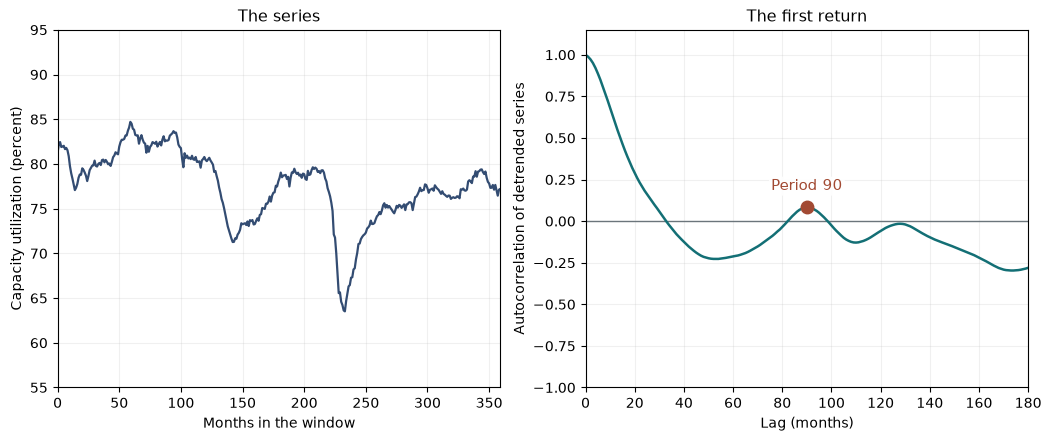

- **Window:** 1990 to 2019
- **Series:** record
- **Dominant period:** 90 months
- **Amplitude (points):** 17.96
- **Mean utilization (points):** 77.5

Amplitude = largest minus smallest value of the straight-line-detrended series = 17.96 points, and the period is the lag of the first local peak of the autocorrelation after it first crosses zero: 90 months. The raw range is 84.7 - 63.5 = 21.2 points, wider because the record drifts down. The autocorrelation at the period is 0.083, a weak return, and the statistic is a first-return measure.

In [18]:
show(score_statistics(window='fit', series='record'))

**Use the idea.** Fit a cycle on its period and amplitude, and report the holdout window beside the fit window.

**Where the conclusion applies.** A straight-line trend, a first-return period statistic, and an amplitude that one spike can set. The period statistic fails when the autocorrelation bumps twice before the real return.

*Constructed example on the published public record: the windows are the chapter's fit and holdout windows, and the model is fitted to the first.*

Every setting the interactive reader offers for this demonstration:

In [19]:
sweep(score_statistics, [('window', ['fit', 'holdout']), ('series', ['record', 'model'])])

- **window = fit, series = record**: Window 1990 to 2019; Series record; Dominant period 90 months; Amplitude (points) 17.96; Mean utilization (points) 77.5
- **window = fit, series = model**: Window 1990 to 2019; Series fitted model, sampled at the same months; Dominant period 90 months; Amplitude (points) 17.47; Mean utilization (points) 71.8; Record period (months) 90; Record amplitude (points) 17.96; Period error (percent) 0.0; Amplitude error (percent) 2.8
- **window = holdout, series = record**: Window 1972 to 1989; Series record; Dominant period 64 months; Amplitude (points) 18.67; Mean utilization (points) 79.9
- **window = holdout, series = model**: Window 1972 to 1989; Series fitted model, sampled at the same months; Dominant period 85 months; Amplitude (points) 17.25; Mean utilization (points) 71.7; Record period (months) 64; Record amplitude (points) 18.67; Period error (percent) 32.8; Amplitude error (percent) 7.6

## 2. Sensible at every step, and still a cycle

*Which investment rule cycles, and does that depend on where demand sits?*

Build when margins are good responds to a margin that is six months old and lands plants eighteen months later, so the response arrives after the signal has gone. Responding to current utilization removes part of that lag and shrinks the swing; a dead band alone does not, and still cycles at both demand levels.

    margins within a tenth of normal trigger nothing

**Symbols and inputs.** Utilization is percent of capacity. Demand is held constant, 80 or 84 in these states. The period is in months and the amplitude in percentage points.

**Predict first.** At a demand of 80 does the dead band rule cycle, and at a demand of 84?

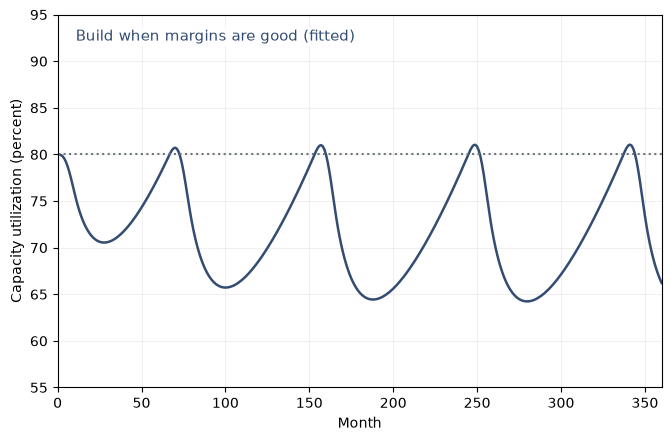

- **Rule:** Build when margins are good (fitted)
- **Demand (held constant):** 80
- **Period:** 90 months
- **Amplitude (points):** 17.5
- **Mean utilization:** 71.8
- **Highest and lowest:** 81.1 and 64.2
- **Mean bound (at least 74):** breaks
- **Amplitude bound (at most 17.96):** meets

Highest minus lowest = 81.05 - 64.24 = 16.81 points, and the detrended amplitude is 17.5. Mean utilization 71.8 against the record's 77.5 is (-5.7) points, and against the mean bound of 74 it breaks that bound (71.8 - 74 = (-2.2)). The cycle comes from the delays in the loop, with demand held fixed. Demand is a constructed setting, and the rules are run on the fitted structure.

In [20]:
show(rule_cycle(rule='build_when_margins_good', demand=80.0))

**Use the idea.** Test a rule at the demand levels it may face, not only at the one it was tuned on.

**Where the conclusion applies.** Constant demand, a fifteen-year lifetime, and no entry or bankruptcy. A rule that looks calm at one demand level may swing hard at another, as the utilization trigger does at 84.

*Constructed example on the published public record: the structure is fitted to it, the rules are the chapter's constructed rules, and the demand of 84 is a constructed value.*

Every setting the interactive reader offers for this demonstration:

In [21]:
sweep(rule_cycle, [('rule', ['build_when_margins_good', 'utilisation_trigger', 'smoothed_margin_trigger', 'fixed_replacement']), ('demand', [80.0, 84.0])])

- **rule = build_when_margins_good, demand = 80.0**: Rule Build when margins are good (fitted); Demand (held constant) 80; Period 90 months; Amplitude (points) 17.5; Mean utilization 71.8; Highest and lowest 81.1 and 64.2; Mean bound (at least 74) breaks; Amplitude bound (at most 17.96) meets
- **rule = build_when_margins_good, demand = 84.0**: Rule Build when margins are good (fitted); Demand (held constant) 84; Period 99 months; Amplitude (points) 29.1; Mean utilization 68.5; Highest and lowest 84.0 and 55.7; Mean bound (at least 74) breaks; Amplitude bound (at most 17.96) breaks
- **rule = utilisation_trigger, demand = 80.0**: Rule Utilization trigger; Demand (held constant) 80; Period 44 months; Amplitude (points) 6.3; Mean utilization 77.7; Highest and lowest 80.0 and 73.8; Mean bound (at least 74) meets; Amplitude bound (at most 17.96) meets
- **rule = utilisation_trigger, demand = 84.0**: Rule Utilization trigger; Demand (held constant) 84; Period 87 months; Amplitude (points) 22.2; Mean utilization 75.7; Highest and lowest 84.0 and 62.7; Mean bound (at least 74) meets; Amplitude bound (at most 17.96) breaks
- **rule = smoothed_margin_trigger, demand = 80.0**: Rule Margin rule with a dead band; Demand (held constant) 80; Period 82 months; Amplitude (points) 16.2; Mean utilization 73.3; Highest and lowest 81.3 and 66.6; Mean bound (at least 74) breaks; Amplitude bound (at most 17.96) meets
- **rule = smoothed_margin_trigger, demand = 84.0**: Rule Margin rule with a dead band; Demand (held constant) 84; Period 95 months; Amplitude (points) 26.2; Mean utilization 70.3; Highest and lowest 84.0 and 58.4; Mean bound (at least 74) breaks; Amplitude bound (at most 17.96) breaks
- **rule = fixed_replacement, demand = 80.0**: Rule Fixed replacement; Demand (held constant) 80; Period undefined (the autocorrelation never returns to a positive peak); Amplitude (points) 0.0; Mean utilization 80.0; Highest and lowest 80.0 and 80.0; Mean bound (at least 74) meets; Amplitude bound (at most 17.96) meets
- **rule = fixed_replacement, demand = 84.0**: Rule Fixed replacement; Demand (held constant) 84; Period undefined (the autocorrelation never returns to a positive peak); Amplitude (points) 0.0; Mean utilization 84.0; Highest and lowest 84.0 and 84.0; Mean bound (at least 74) meets; Amplitude bound (at most 17.96) meets

## 3. The construction delay carries the period

*How far does the model's period move as the construction delay changes?*

A longer delay holds more plants in progress when the margin turns, so the swing takes longer to reverse. The gain changes how hard the loop pushes against that delay.

    The construction delay sets the period.

**Symbols and inputs.** The construction delay is in months. The investment gain is capacity growth per month per unit of excess margin. The period is a lag in months.

**Predict first.** If the construction delay rises from 18 to 48 months, does the period rise in proportion?

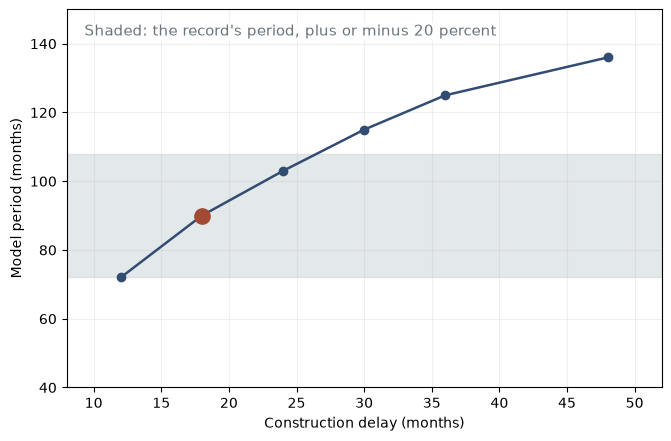

- **Construction delay:** 18 months
- **Investment gain:** 0.25
- **Model period:** 90 months
- **Model amplitude (points):** 17.5
- **Record period:** 90 months

Period error = |90 - 90| / 90 = 0.0 percent, inside the 20 percent tolerance. Only the delay and the gain differ between the points, the rest held at the fitted values. The fitted delay of 18 months is a property of an aggregate and the fit, not the time to build a plant, and the gain of 0.25 is the fitted value.

In [22]:
show(delay_sets_period(delay=18.0, gain=0.25))

**Use the idea.** Measure a delay before fitting it, since a fitted delay of an aggregate is not a build time.

**Where the conclusion applies.** The perception delay, lifetime and margin sensitivity stay at the fitted values. The record cannot tell this loop from a driven one.

*Constructed example on the published public record: the sweep is the chapter's, and a gain of 0.15 is a constructed value beside the fitted 0.25.*

Every setting the interactive reader offers for this demonstration:

In [23]:
sweep(delay_sets_period, [('delay', [12.0, 18.0, 30.0, 48.0]), ('gain', [0.15, 0.25])])

- **delay = 12.0, gain = 0.15**: Construction delay 12 months; Investment gain 0.15; Model period 65 months; Model amplitude (points) 13.6; Record period 90 months
- **delay = 12.0, gain = 0.25**: Construction delay 12 months; Investment gain 0.25; Model period 72 months; Model amplitude (points) 15.3; Record period 90 months
- **delay = 18.0, gain = 0.15**: Construction delay 18 months; Investment gain 0.15; Model period 81 months; Model amplitude (points) 15.2; Record period 90 months
- **delay = 18.0, gain = 0.25**: Construction delay 18 months; Investment gain 0.25; Model period 90 months; Model amplitude (points) 17.5; Record period 90 months
- **delay = 30.0, gain = 0.15**: Construction delay 30 months; Investment gain 0.15; Model period 102 months; Model amplitude (points) 15.9; Record period 90 months
- **delay = 30.0, gain = 0.25**: Construction delay 30 months; Investment gain 0.25; Model period 115 months; Model amplitude (points) 19.3; Record period 90 months
- **delay = 48.0, gain = 0.15**: Construction delay 48 months; Investment gain 0.15; Model period 123 months; Model amplitude (points) 15.6; Record period 90 months
- **delay = 48.0, gain = 0.25**: Construction delay 48 months; Investment gain 0.25; Model period 136 months; Model amplitude (points) 19.0; Record period 90 months

## 4. A period is not a date

*How far does the next trough move if only the starting point in the cycle changes?*

The same loop started at a different point in its cycle puts its first trough in a different year, because the pipeline of plants already ordered differs.

    A model that reproduces a period does not predict a date.

**Symbols and inputs.** The start is utilization in percent at month 0. Demand is 80, so starting capacity is 100 x 80 / start in index units. Months count from the start.

**Predict first.** Do the first troughs of a start at 70 and a start at 86 fall within ten months of each other?

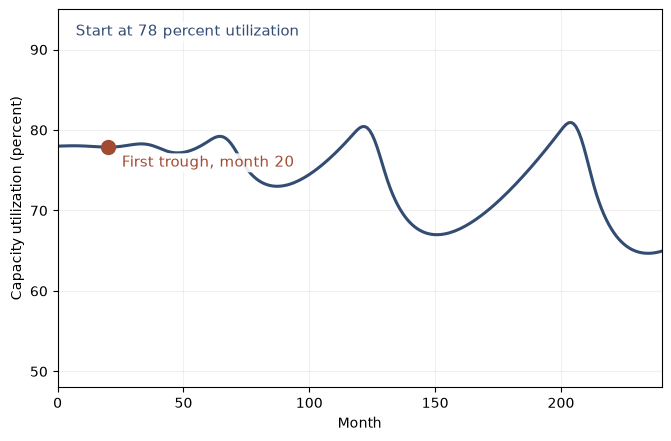

- **Start utilization:** 78
- **Starting capacity (index):** 102.6
- **First trough (month):** 20

Starting capacity = 100 x 80 / 78 = 102.6, so demand of 80 meets a utilization of 78 percent at month 0. The first trough falls at month 20. Switch to all five starts to see how far the same structure's trough date moves. The starting points are constructed settings, not records.

In [24]:
show(phase_start(start=78.0, view='alone'))

**Use the idea.** To forecast a date you need the state of the pipeline, not a better fit.

**Where the conclusion applies.** Only the starting capacity changes. The pipeline of plants ordered is not measured in the record, and the starts are constructed.

*Constructed example on the published public record: the structure is fitted to it, and the starting utilizations are constructed values.*

Every setting the interactive reader offers for this demonstration:

In [25]:
sweep(phase_start, [('start', [70.0, 78.0, 86.0]), ('view', ['alone', 'all five'])])

- **start = 70.0, view = alone**: Start utilization 70; Starting capacity (index) 114.3; First trough (month) 72
- **start = 70.0, view = all five**: Start utilization 70; Starting capacity (index) 114.3; First trough (month) 72; First trough spread, five starts (months) 52; Band across the five paths at month 120 (points) 14.4; Widest band (points) 30.2
- **start = 78.0, view = alone**: Start utilization 78; Starting capacity (index) 102.6; First trough (month) 20
- **start = 78.0, view = all five**: Start utilization 78; Starting capacity (index) 102.6; First trough (month) 20; First trough spread, five starts (months) 52; Band across the five paths at month 120 (points) 14.4; Widest band (points) 30.2
- **start = 86.0, view = alone**: Start utilization 86; Starting capacity (index) 93.0; First trough (month) 40
- **start = 86.0, view = all five**: Start utilization 86; Starting capacity (index) 93.0; First trough (month) 40; First trough spread, five starts (months) 52; Band across the five paths at month 120 (points) 14.4; Widest band (points) 30.2

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If a model cycles at 85 months where the record cycles at 64, what is the period error?

<details><summary>Answer</summary>

|85 - 64| / 64 = 21 / 64 = 0.328, which is 32.8 percent, outside the 20 percent tolerance.

</details>

### Exercise 2

A path peaks at 81.1 and troughs at 64.2. What is the raw range?

<details><summary>Answer</summary>

81.1 - 64.2 = 16.9 points before the straight line is removed (16.8 from the unrounded values 81.05 and 64.24).

</details>

### Exercise 3

If the model period is 105 months and the record's is 90, what is the period error?

<details><summary>Answer</summary>

|105 - 90| / 90 = 15 / 90 = 0.167, which is 16.7 percent.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/